# Gaussian Process Emulators, from the ground up

You already know what an emulator is *for*: you have some expensive function
$f(\mathbf{x})$ — a Boltzmann solver, an N-body sim, a radiative transfer code — you can
afford to evaluate it maybe a few thousand times, and you want a cheap stand-in that
returns essentially the same answer in microseconds.

This notebook is about one particular way to build that stand-in: a **Gaussian Process**
(GP). It assumes you have *never used one* and do not know how they work. So we build the
machinery from multivariate Gaussians upward, in `numpy`, with every matrix written out.
No GP library is used anywhere — by the end you will have written one.

### Why a GP is an appealing emulator

| Property | Why it matters for emulation |
|---|---|
| Interpolates exactly | With noise-free simulator output, the emulator reproduces training points to machine precision |
| Returns a **predictive variance**, not just a mean | You know where the emulator is untrustworthy — invaluable when the emulator feeds an MCMC |
| Works with few training points | Competitive at $N \sim 10^2$–$10^3$, where a neural net is still flailing |
| Very few knobs | Typically 2–8 hyperparameters, fit by maximising a likelihood — no architecture search |
| Non-parametric | You choose smoothness assumptions, not a functional form |

And the honest counterweight, which we will demonstrate rather than assert:

| Limitation | Consequence |
|---|---|
| $\mathcal{O}(N^3)$ training, $\mathcal{O}(N^2)$ memory | Plain GPs run out of road around $N \sim 10^4$ |
| Extrapolation is governed entirely by the prior | Outside the training region a GP returns its prior mean, confidently-ish |
| The error bars are *conditional on the kernel being right* | A misspecified kernel gives wrong predictions **and** wrong uncertainties |

### Roadmap

1. **Gaussians → functions.** The single conceptual leap. A distribution over functions is just a very large multivariate Gaussian.
2. **The kernel.** Where every assumption you make actually lives.
3. **Conditioning.** GP regression *is* the Gaussian conditioning formula. This is the whole algorithm.
4. **Numerics.** Cholesky, jitter, and why you must never write `np.linalg.inv`.
5. **Noise.** Interpolation vs. regression, and the nugget term.
6. **Hyperparameters.** The log marginal likelihood, its built-in Occam's razor, and its gradients.
7. **The kernel zoo.** Matérn, periodic, linear, and how to combine them.
8. **Mean functions.** Why GPs revert to the prior, and how to stop them.
9. **The test:** $y(x) = x^3 + 0.1\sin(2x)$ — a huge trend plus a ripple worth only 0.4% of the signal.
10. **A JAX implementation** with autodiff gradients, verified against the `numpy` one.
11. **Practical guidance** for scaling this up to a real emulator.

Everything is 1-D so that you can *see* every object we compute. The code is written for
$(n, d)$ input arrays throughout, though, so it transfers to many input dimensions unchanged.

In [20]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import cho_factor, cho_solve, solve_triangular
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True, linewidth=110)
RNG = np.random.default_rng(20260810)   # one seed for the whole notebook

# ---------------------------------------------------------------- plotting style
SURF, GRID, AXIS, MUTED = "#fcfcfb", "#e1e0d9", "#c3c2b7", "#898781"
INK, INK2 = "#0b0b0b", "#52514e"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"   # categorical slots 1-3
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
BLUES = LinearSegmentedColormap.from_list("blues", SEQ)

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "medium",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-", "axes.grid": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5, "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 8.5, "legend.labelcolor": INK2,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round",
    "font.size": 10, "figure.dpi": 118, "axes.axisbelow": True,
    "figure.max_open_warning": 0,
})

def dots(ax, x, y, color=INK, size=34, label=None, zorder=6):
    '''Observation markers: a 2px surface ring keeps overlapping points readable.'''
    return ax.scatter(x, y, s=size, c=color, edgecolors=SURF, linewidths=1.4,
                      zorder=zorder, label=label)

def band(ax, x, mu, sd, color=C1, label=r"$\pm 2\sigma$"):
    '''Predictive interval: two nested ribbons at 1 and 2 sigma.'''
    ax.fill_between(x, mu - 2*sd, mu + 2*sd, color=color, alpha=0.15, lw=0, label=label)
    ax.fill_between(x, mu - sd,   mu + sd,   color=color, alpha=0.15, lw=0)

print("numpy", np.__version__)

numpy 2.5.1


---
## 1. The one conceptual leap: Gaussians over functions

Everything about GPs follows from one re-interpretation of the multivariate normal
distribution. Let us build up to it in three steps.

### 1.1 Step one — a 2-D Gaussian is a statement about *correlation*

Take two random numbers $(f_1, f_2)$ with

$$
\begin{pmatrix} f_1 \\ f_2 \end{pmatrix} \sim
\mathcal{N}\!\left( \begin{pmatrix} 0 \\ 0 \end{pmatrix},\;
\begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix} \right).
$$

The interesting parameter is $\rho$. When $\rho = 0$ the two values know nothing about each
other. As $\rho \to 1$ they are welded together: *learning $f_1$ tells you $f_2$ almost
exactly*. That last sentence is the entire predictive mechanism of a Gaussian process. Watch
the third panel below — the cloud collapses onto a line, so conditioning on $f_1 = 1.5$
leaves almost no freedom in $f_2$.

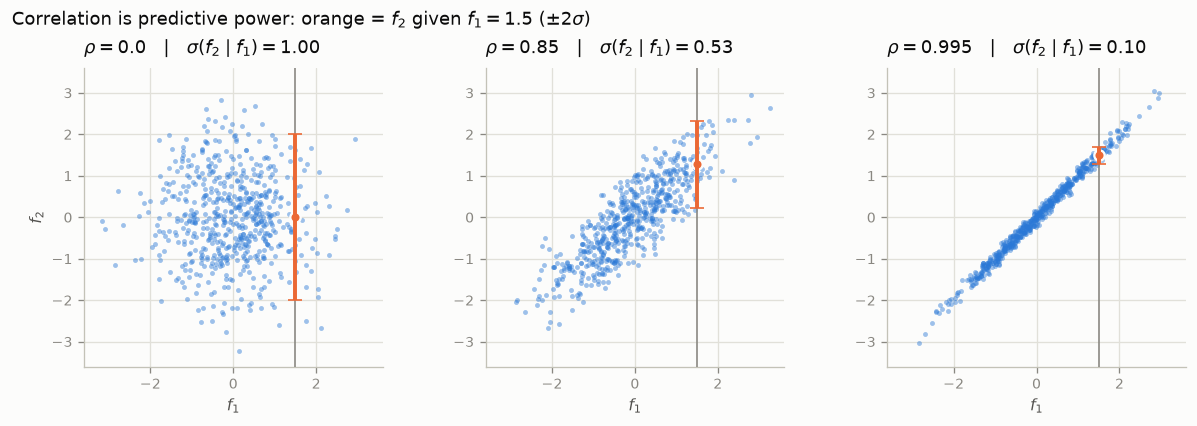

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.5), constrained_layout=True)
for ax, rho in zip(axes, [0.0, 0.85, 0.995]):
    cov = np.array([[1.0, rho], [rho, 1.0]])
    s = RNG.multivariate_normal([0, 0], cov, size=600)
    ax.scatter(s[:, 0], s[:, 1], s=9, c=C1, alpha=0.45, lw=0)

    # conditional distribution of f2 given f1 = 1.5  (the formula arrives in section 3)
    x0 = 1.5
    m_c, s_c = rho * x0, np.sqrt(1 - rho**2)
    ax.axvline(x0, color=MUTED, lw=1.0, zorder=3)
    ax.errorbar([x0], [m_c], yerr=[2 * s_c], color=C2, lw=2.4, capsize=4, zorder=7)
    dots(ax, [x0], [m_c], color=C2, size=40)

    ax.set(xlim=(-3.6, 3.6), ylim=(-3.6, 3.6), xlabel="$f_1$",
           ylabel="$f_2$" if ax is axes[0] else None,
           title=rf"$\rho = {rho}$   |   $\sigma(f_2 \mid f_1) = {s_c:.2f}$")
    ax.set_aspect("equal")
fig.suptitle("Correlation is predictive power: orange = $f_2$ given $f_1=1.5$ ($\\pm2\\sigma$)",
             fontsize=11, color=INK, x=0.01, ha="left")
plt.show()

### 1.2 Step two — re-index the components by *position*

Nothing forces us to call those two numbers "component 1" and "component 2". Let us say
instead that they are the values of some function $f$ at two locations, $x_1 = 0$ and
$x_2 = 0.3$:

$$ f_1 \equiv f(x_1), \qquad f_2 \equiv f(x_2). $$

Now the covariance has a natural reading: $\rho$ is *how strongly the function's value at
$x_1$ constrains its value at $x_2$*. And if that is a statement about the two locations,
we should write it as a function of them:

$$ \operatorname{Cov}[f(x), f(x')] = k(x, x'). $$

This $k$ is the **kernel** (or covariance function). Physically we expect nearby points to
be strongly correlated and distant points to be nearly independent, so $k$ should decay with
$|x - x'|$.

### 1.3 Step three — do it for $n$ points at once, then let $n \to \infty$

Pick any finite set of locations $X = \{x_1, \dots, x_n\}$. Build the $n \times n$ matrix
$K_{ij} = k(x_i, x_j)$. Then declare

$$ \mathbf{f} = \big(f(x_1), \dots, f(x_n)\big)^\top \sim \mathcal{N}\big(\mathbf{m}, K\big),
\qquad m_i = m(x_i). $$

> **Definition.** A **Gaussian process** is a collection of random variables, any finite
> subset of which is jointly Gaussian. We write $f \sim \mathcal{GP}\big(m(x), k(x,x')\big)$.
> It is completely specified by its mean function $m$ and kernel $k$.

The leap is this: **a function evaluated on a grid is just a vector, so a distribution over
functions is just a distribution over vectors.** Take $n = 200$ grid points and plot the
resulting 200-vector as a curve, and you are looking at a *sample function* drawn from a
distribution over functions.

There is no approximation in the $n\to\infty$ business. The definition is *consistent*: the
distribution you get on any subset of points by marginalising a bigger set is the same one
you would have written down directly. That is why we can always work with only the finite
set of points we actually care about — which is what makes GPs computable at all.

Let us draw some. The standard first kernel is the **squared exponential** (a.k.a. RBF,
Gaussian, radial basis function):

$$ k_{\mathrm{SE}}(x, x') = \sigma_f^2 \exp\!\left( -\frac{(x - x')^2}{2\ell^2} \right). $$

Two parameters: $\sigma_f^2$ sets the *variance* (how far the function roams from its mean)
and $\ell$ the **lengthscale** (how far you must move in $x$ before the function changes
appreciably).

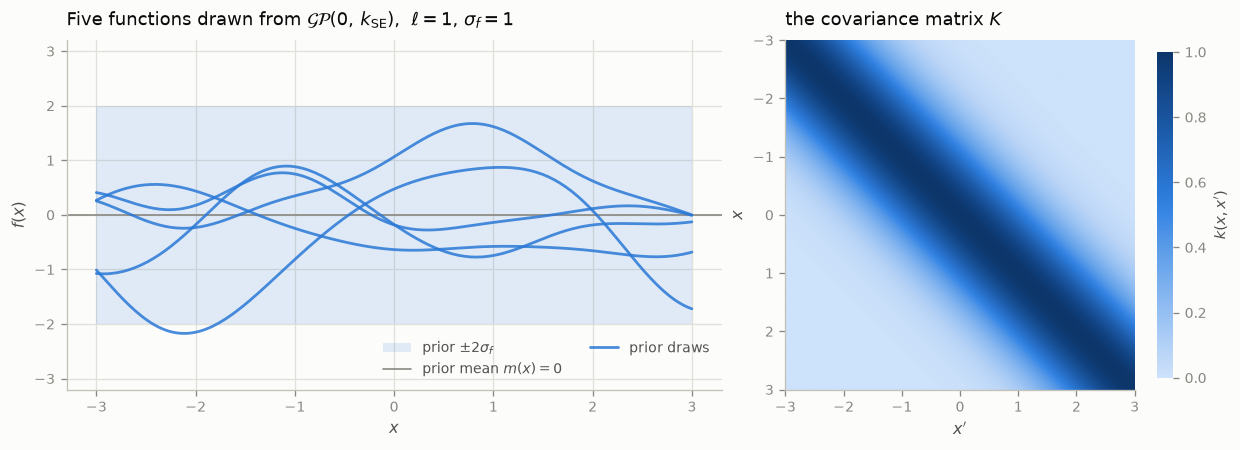

K is 200 x 200, symmetric: True, diagonal = sigma_f^2 = 1.0


In [22]:
def sqdist(A, B):
    '''Pairwise squared Euclidean distances between rows of A (n,d) and B (m,d).'''
    A = np.atleast_2d(A); B = np.atleast_2d(B)
    return np.maximum(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1), 0.0)

def k_se(A, B, var=1.0, ell=1.0):
    '''Squared-exponential kernel. `ell` may be a scalar or a length-d vector (ARD).'''
    A = np.atleast_2d(A) / np.asarray(ell)
    B = np.atleast_2d(B) / np.asarray(ell)
    return var * np.exp(-0.5 * sqdist(A, B))

def draw_gp(x, kernel, n_samples=5, jitter=1e-10, rng=RNG):
    '''Sample functions from a zero-mean GP prior on the grid `x`.'''
    X = x.reshape(-1, 1)
    K = kernel(X, X) + jitter * np.eye(len(x))
    L = np.linalg.cholesky(K)                      # K = L L^T
    return (L @ rng.standard_normal((len(x), n_samples))).T   # (n_samples, n)

x = np.linspace(-3, 3, 200)
samples = draw_gp(x, lambda A, B: k_se(A, B, var=1.0, ell=1.0), n_samples=5)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(10.4, 3.7),
                               gridspec_kw={"width_ratios": [1.85, 1]}, constrained_layout=True)
axa.fill_between(x, -2, 2, color=C1, alpha=0.13, lw=0, label=r"prior $\pm 2\sigma_f$")
axa.axhline(0, color=MUTED, lw=1.0, label="prior mean $m(x)=0$")
for i, s in enumerate(samples):
    axa.plot(x, s, color=C1, lw=1.7, alpha=0.85, label="prior draws" if i == 0 else None)
axa.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-3.2, 3.2),
        title=r"Five functions drawn from $\mathcal{GP}(0,\,k_{\rm SE})$,  $\ell=1$, $\sigma_f=1$")
axa.legend(loc="lower right", ncol=2)

im = axb.imshow(k_se(x.reshape(-1, 1), x.reshape(-1, 1)), cmap=BLUES,
                extent=[-3, 3, 3, -3], vmin=0, vmax=1)
axb.grid(False)
axb.set(xlabel="$x'$", ylabel="$x$", title="the covariance matrix $K$")
cb = fig.colorbar(im, ax=axb, fraction=0.046)
cb.set_label("$k(x,x')$", color=INK2, fontsize=9); cb.outline.set_visible(False)
plt.show()

print("K is %d x %d, symmetric: %s, diagonal = sigma_f^2 = %.1f"
      % (len(x), len(x), np.allclose(k_se(x.reshape(-1,1), x.reshape(-1,1)),
                                     k_se(x.reshape(-1,1), x.reshape(-1,1)).T),
         k_se(np.zeros((1,1)), np.zeros((1,1)))[0,0]))

Take a moment on that pair of panels, because they contain the whole idea.

- We never wrote down a functional form. No polynomial degree, no basis expansion, no
  network architecture. We specified *only* how correlated the function is with itself at
  different separations — and out came smooth, wiggly, plausible functions.
- The **bright diagonal band** in $K$ is the entire mechanism. Points near each other
  ($|x-x'| \lesssim \ell$) have covariance near $\sigma_f^2$, so their values must agree;
  points far apart have covariance $\approx 0$ and vary independently. Smoothness *is* that
  band.
- Every draw wanders inside the $\pm 2\sigma_f$ ribbon, crossing the mean on a
  characteristic scale $\ell$. That ribbon is the prior uncertainty: before seeing data, this
  is all the GP claims to know.

**The kernel is the model.** Choosing $k$ is the modelling act; everything after it is
linear algebra.

---
## 2. The kernel is where your assumptions live

Not every function of two arguments is a legal kernel. Since $K$ must be a valid covariance
matrix, $k$ must be **symmetric** and **positive semi-definite**: for *any* finite set of
points, $\mathbf{v}^\top K \mathbf{v} \ge 0$ for all $\mathbf{v}$. (Practically: build kernels
from known-valid ones — the sum and product of valid kernels are valid, which is what makes
the compositional approach in section 7 safe.)

The SE kernel's two parameters do quite different jobs. Below, each panel is one small
multiple; only the labelled parameter changes.

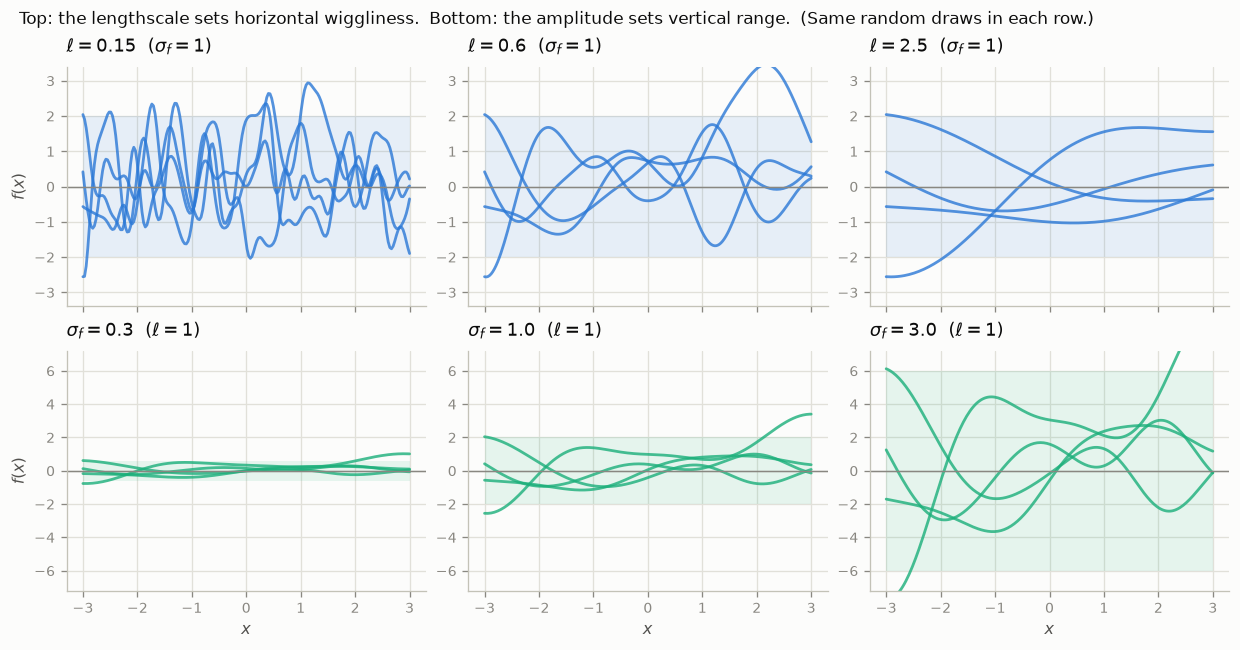

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(10.4, 5.4), sharex=True, constrained_layout=True)
x = np.linspace(-3, 3, 200)

for ax, ell in zip(axes[0], [0.15, 0.6, 2.5]):
    for s in draw_gp(x, lambda A, B: k_se(A, B, 1.0, ell), 4, rng=np.random.default_rng(3)):
        ax.plot(x, s, color=C1, lw=1.7, alpha=0.8)
    ax.fill_between(x, -2, 2, color=C1, alpha=0.10, lw=0)
    ax.set(ylim=(-3.4, 3.4), title=rf"$\ell = {ell}$  ($\sigma_f = 1$)")
    ax.axhline(0, color=MUTED, lw=0.9)

for ax, sf in zip(axes[1], [0.3, 1.0, 3.0]):
    for s in draw_gp(x, lambda A, B: k_se(A, B, sf**2, 1.0), 4, rng=np.random.default_rng(3)):
        ax.plot(x, s, color=C3, lw=1.7, alpha=0.8)
    ax.fill_between(x, -2*sf, 2*sf, color=C3, alpha=0.10, lw=0)
    ax.set(ylim=(-7.2, 7.2), xlabel="$x$", title=rf"$\sigma_f = {sf}$  ($\ell = 1$)")
    ax.axhline(0, color=MUTED, lw=0.9)

axes[0, 0].set_ylabel("$f(x)$"); axes[1, 0].set_ylabel("$f(x)$")
fig.suptitle("Top: the lengthscale sets horizontal wiggliness.  "
             "Bottom: the amplitude sets vertical range.  (Same random draws in each row.)",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

Reading that figure, in emulator terms:

- **$\ell$ is your smoothness / resolution assumption.** It says: "my function does not do
  anything interesting on scales shorter than $\ell$." If you set $\ell$ too long you will
  smooth over real features; too short and the GP will not generalise between training
  points — it reverts to the prior mean in the gaps. Getting $\ell$ right is most of the
  game, which is why section 6 fits it from data rather than guessing.
- **$\sigma_f$ is your dynamic-range assumption**, in the units of $y$. Note that the same
  underlying random draws appear in both rows: changing $\sigma_f$ just rescales the
  $y$-axis, while changing $\ell$ genuinely changes the *shape*.
- For $d$-dimensional input you get one lengthscale **per dimension**,
  $k = \sigma_f^2\exp\!\big(-\tfrac12\sum_{i=1}^{d} (x_i-x_i')^2/\ell_i^2\big)$. This is called
  **ARD** (automatic relevance determination): a fitted $\ell_i$ much larger than the range
  of input $i$ means the output barely depends on that input. For a cosmological emulator
  that is a free sensitivity analysis — the lengthscales rank your parameters by importance.
  Our `k_se` already accepts a vector `ell`, so this works out of the box.

---
## 3. Conditioning: this *is* GP regression

Here is the payoff. We have a prior over functions. We observe some data. We want the
posterior over functions. Because everything is jointly Gaussian, that posterior is available
in closed form — no MCMC, no variational bound, no iterative fitting. Two lines of linear
algebra.

### 3.1 The Gaussian conditioning identity

This is the one piece of mathematics to actually remember. If a joint Gaussian is partitioned
into two blocks,

$$
\begin{pmatrix} \mathbf{a} \\ \mathbf{b} \end{pmatrix} \sim
\mathcal{N}\!\left(
\begin{pmatrix} \boldsymbol{\mu}_a \\ \boldsymbol{\mu}_b \end{pmatrix},\;
\begin{pmatrix} A & C \\ C^\top & B \end{pmatrix}
\right),
$$

then the conditional distribution of $\mathbf{b}$ given an observed $\mathbf{a}$ is *also*
Gaussian:

$$
\boxed{\;\mathbf{b} \mid \mathbf{a} \;\sim\; \mathcal{N}\Big(
\boldsymbol{\mu}_b + C^\top A^{-1}(\mathbf{a} - \boldsymbol{\mu}_a),\;\;
B - C^\top A^{-1} C \Big)\;}
$$

Two things to notice, because they explain everything a GP does:

- The **mean** gets corrected by $C^\top A^{-1}(\mathbf{a}-\boldsymbol{\mu}_a)$ — a linear
  function of how surprising the data was. If the data came out exactly at the prior mean,
  nothing changes.
- The **covariance** shrinks by $C^\top A^{-1} C$, which is positive semi-definite, and
  crucially **does not depend on the observed values $\mathbf{a}$ at all** — only on *where*
  you observed. This is why a GP can tell you the uncertainty of a proposed training design
  before you have run a single simulation.

(Sanity check against section 1.1: with scalars $A=B=1$, $C=\rho$, we get
$\mathbb{E}[f_2|f_1] = \rho f_1$ and $\operatorname{Var} = 1-\rho^2$ — exactly the orange
error bars we drew.)

### 3.2 Apply it to a GP

Let $X$ be the $n$ training inputs and $\mathbf{y}$ the observed outputs, possibly with
independent Gaussian noise of variance $\sigma_n^2$. Let $X_*$ be the $m$ points where we
want predictions. Write

$$ K = k(X,X)\;(n\times n), \qquad K_* = k(X,X_*)\;(n\times m), \qquad K_{**} = k(X_*,X_*)\;(m\times m). $$

The GP definition says the training outputs and the test function values are *jointly*
Gaussian:

$$
\begin{pmatrix} \mathbf{y} \\ \mathbf{f}_* \end{pmatrix} \sim
\mathcal{N}\!\left(
\begin{pmatrix} \mathbf{m} \\ \mathbf{m}_* \end{pmatrix},\;
\begin{pmatrix} K + \sigma_n^2 I & K_* \\ K_*^\top & K_{**} \end{pmatrix}
\right).
$$

Now just read off the identity with $\mathbf{a} = \mathbf{y}$, $\mathbf{b} = \mathbf{f}_*$:

$$
\boxed{
\begin{aligned}
\boldsymbol{\mu}_* &= \mathbf{m}_* + K_*^\top \big(K + \sigma_n^2 I\big)^{-1} (\mathbf{y}-\mathbf{m}) \\[4pt]
\Sigma_* &= K_{**} - K_*^\top \big(K + \sigma_n^2 I\big)^{-1} K_*
\end{aligned}}
$$

**That is the entire algorithm.** Every GP regression package on earth computes these two
expressions. Note what the mean is: $\boldsymbol{\mu}_* = \mathbf{m}_* + \sum_i \alpha_i k(x_i, x_*)$
with $\boldsymbol{\alpha} = (K+\sigma_n^2 I)^{-1}(\mathbf{y}-\mathbf{m})$ — a **weighted sum of
kernel functions centred on the training points**. The GP prediction is a smooth
interpolation kernel, automatically weighted so as to honour the data.

Let us write it naively — literally as typed above — and look at what comes out.

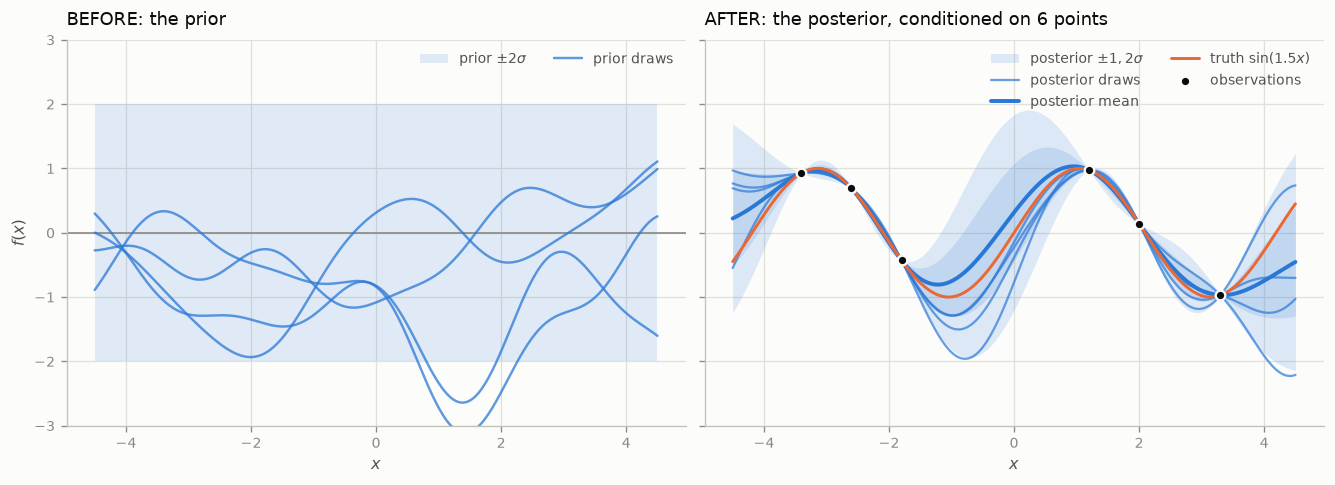

posterior sd exactly at the observations : 1.00e-05   (= sqrt(jitter) = 1e-05)
posterior sd in the middle of the gap    : 0.802
posterior sd at the edge of the plot     : 0.843   (prior sd = 1.000)


In [24]:
def gp_posterior_naive(X, y, Xs, kernel, noise_var=0.0, mean=0.0, jitter=1e-10):
    '''GP posterior, written exactly like the boxed equations. Not how to do it (see S4).'''
    X, Xs = np.atleast_2d(X), np.atleast_2d(Xs)
    n = len(X)
    K   = kernel(X,  X) + (noise_var + jitter) * np.eye(n)
    Ks  = kernel(X,  Xs)                       # (n, m)
    Kss = kernel(Xs, Xs)                       # (m, m)

    Kinv_y  = np.linalg.solve(K, y - mean)     # (K + sn^2 I)^-1 (y - m)
    Kinv_Ks = np.linalg.solve(K, Ks)           # (K + sn^2 I)^-1 K_*

    mu    = mean + Ks.T @ Kinv_y               # posterior mean      (m,)
    Sigma = Kss - Ks.T @ Kinv_Ks               # posterior covariance (m, m)
    return mu, Sigma

# ------------------------------------------------------------------ a demo problem
f_demo = lambda t: np.sin(1.5 * t)

x_tr = np.array([-3.4, -2.6, -1.8, 1.2, 2.0, 3.3])   # note the deliberate gap in the middle
y_tr = f_demo(x_tr)
x_gr = np.linspace(-4.5, 4.5, 300)

kern = lambda A, B: k_se(A, B, var=1.0, ell=1.0)
mu, Sigma = gp_posterior_naive(x_tr.reshape(-1,1), y_tr, x_gr.reshape(-1,1), kern)
sd = np.sqrt(np.clip(np.diag(Sigma), 0, None))

# draw functions from the POSTERIOR: same trick as before, but with Sigma
L_post = np.linalg.cholesky(Sigma + 1e-9*np.eye(len(x_gr)))
post_draws = (mu[:, None] + L_post @ RNG.standard_normal((len(x_gr), 4))).T

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11.2, 4.0), sharey=True, constrained_layout=True)

axa.fill_between(x_gr, -2, 2, color=C1, alpha=0.13, lw=0, label=r"prior $\pm2\sigma$")
axa.axhline(0, color=MUTED, lw=1.0)
for i, s in enumerate(draw_gp(x_gr, kern, 4, rng=np.random.default_rng(7))):
    axa.plot(x_gr, s, color=C1, lw=1.5, alpha=0.75, label="prior draws" if i == 0 else None)
axa.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-3.0, 3.0), title="BEFORE: the prior")
axa.legend(loc="upper right", ncol=2)

band(axb, x_gr, mu, sd, C1, label=r"posterior $\pm1,2\sigma$")
for i, s in enumerate(post_draws):
    axb.plot(x_gr, s, color=C1, lw=1.4, alpha=0.7, label="posterior draws" if i == 0 else None)
axb.plot(x_gr, mu, color=C1, lw=2.4, label="posterior mean")
axb.plot(x_gr, f_demo(x_gr), color=C2, lw=1.8, label="truth $\\sin(1.5x)$")
dots(axb, x_tr, y_tr, INK, label="observations")
axb.set(xlabel="$x$", title="AFTER: the posterior, conditioned on 6 points")
axb.legend(loc="upper right", ncol=2)
plt.show()

# evaluate exactly AT a training input, not at the nearest plotting-grid point
sd_obs = np.sqrt(np.clip(np.diag(gp_posterior_naive(
    x_tr.reshape(-1,1), y_tr, x_tr.reshape(-1,1), kern)[1]), 0, None))
print(f"posterior sd exactly at the observations : {sd_obs.max():.2e}"
      f"   (= sqrt(jitter) = {np.sqrt(1e-10):.0e})")
print(f"posterior sd in the middle of the gap    : {sd[np.argmin(abs(x_gr+0.3))]:.3f}")
print(f"posterior sd at the edge of the plot     : {sd[-1]:.3f}   (prior sd = 1.000)")

### 3.3 How to read that right-hand panel

This picture repays careful study — nearly every practical GP behaviour is visible in it.

1. **The band pinches to zero at each observation.** We told the GP the data was noise-free
   ($\sigma_n^2 = 0$), so it interpolates: the posterior sd *at* a training input is $10^{-5}$ —
   exactly $\sqrt{\text{jitter}}$, i.e. numerical zero, set purely by the $10^{-10}$ we added for
   conditioning. Every posterior draw passes through every black dot.
2. **The band bulges in the gap** (sd $\approx 0.8$ near $x=-0.3$, against a prior sd of 1). The
   GP is telling you, in the middle of the plot, "I have not been told what happens here." That is
   the single most valuable output of a GP emulator, and no plain interpolating spline gives it to
   you.
3. **Outside the data the band climbs back toward the prior width** and the mean heads back to the
   prior mean of zero. It is already at 0.84 by the edge of this plot, and reaches $\sigma_f=1$
   within a few more lengthscales (we measure this properly in section 8). The GP does not
   extrapolate the trend; it *forgets*, on a scale of $\ell$. Section 8 is about controlling this,
   and it is the crux of the $x^3$ test in section 9.
4. **The truth (orange) lies inside the band** everywhere — including in the gap, where the
   mean is visibly wrong. The mean being wrong is fine; the mean being wrong *without the band
   noticing* is what we must avoid.
5. **Posterior draws, not just the mean.** The individual draws are still wiggly, but they
   agree wherever data pins them. If your emulator feeds a nonlinear downstream calculation,
   propagating a few posterior draws is a far more honest error estimate than pushing the mean
   through and hoping.

Watching the posterior form as data arrives makes the mechanism concrete:

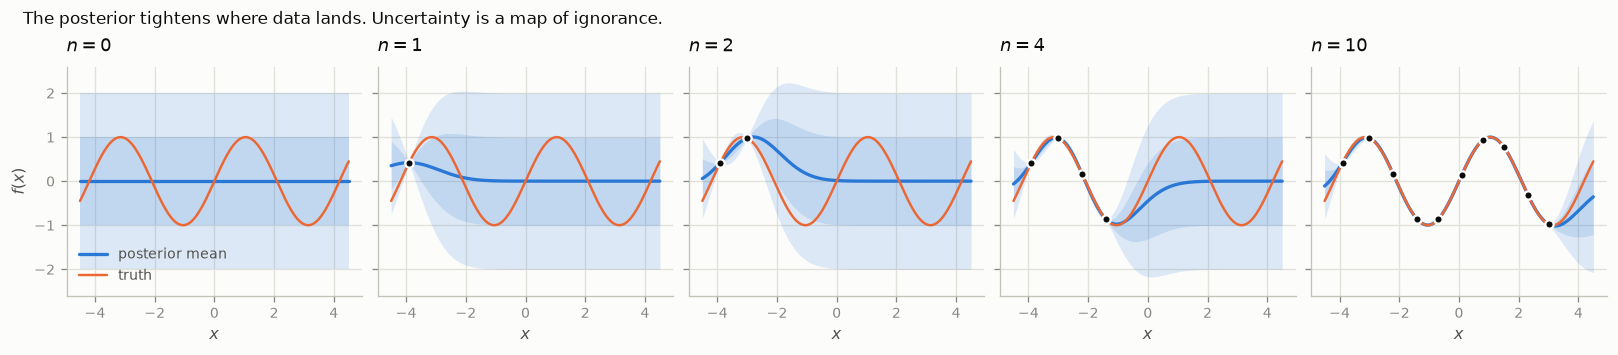

In [25]:
pool_x = np.array([-3.9, -3.0, -2.2, -1.4, -0.7, 0.1, 0.8, 1.5, 2.3, 3.0, 3.7, 4.2,
                   -2.6, -0.3, 1.1, 2.7])
fig, axes = plt.subplots(1, 5, figsize=(13.6, 2.9), sharey=True, sharex=True,
                         constrained_layout=True)
for ax, n in zip(axes, [0, 1, 2, 4, 10]):
    xt = pool_x[:n]; yt = f_demo(xt)
    if n == 0:
        m_, s_ = np.zeros_like(x_gr), np.ones_like(x_gr)
    else:
        m_, S_ = gp_posterior_naive(xt.reshape(-1,1), yt, x_gr.reshape(-1,1), kern)
        s_ = np.sqrt(np.clip(np.diag(S_), 0, None))
    band(ax, x_gr, m_, s_, C1, label=None)
    ax.plot(x_gr, m_, color=C1, lw=2.0)
    ax.plot(x_gr, f_demo(x_gr), color=C2, lw=1.5)
    if n: dots(ax, xt, yt, INK, size=26)
    ax.set(title=f"$n = {n}$", xlabel="$x$", ylim=(-2.6, 2.6))
axes[0].set_ylabel("$f(x)$")
axes[0].plot([], [], color=C1, lw=2.0, label="posterior mean")
axes[0].plot([], [], color=C2, lw=1.5, label="truth")
axes[0].legend(loc="lower left")
fig.suptitle("The posterior tightens where data lands. Uncertainty is a map of ignorance.",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

---
## 4. Doing the linear algebra properly

The naive function above is correct mathematics and poor numerics. Three fixes separate a
toy from a usable implementation.

### 4.1 Never form the inverse — use a Cholesky factorisation

$K$ is symmetric positive-definite, so it factors as $K = LL^\top$ with $L$ lower-triangular.
This costs $\tfrac13 n^3$ flops, about half of an LU solve, and once you have $L$:

$$ \boldsymbol{\alpha} = K^{-1}\mathbf{r} \;\Rightarrow\; \text{solve } L\mathbf{z}=\mathbf{r},
\; L^\top\boldsymbol{\alpha}=\mathbf{z}, \qquad\quad
\log|K| = 2\sum_i \log L_{ii}. $$

That last identity matters enormously. We will need $\log|K|$ for the marginal likelihood, and
computing it as `np.log(np.linalg.det(K))` overflows or underflows to $\pm\infty$ for even
modest $n$ (a determinant is a product of $n$ eigenvalues). Summing $\log L_{ii}$ never does.

Getting the predictive variance right is worth spelling out. Rather than
$K_{**} - K_*^\top K^{-1} K_*$, solve $L\mathbf{v} = K_*$ once and use

$$ \Sigma_* = K_{**} - \mathbf{v}^\top\mathbf{v}, $$

which is cheaper and manifestly symmetric. And when you only need the *marginal* variances
(the error bar at each test point independently — usually all you want), never build the
$m\times m$ matrix at all: take $\operatorname{diag} = k(x_*,x_*) - \sum_i v_{i*}^2$. For
$m = 10^5$ test points that is the difference between a 40 GB allocation and a vector.

### 4.2 Add jitter, because $K$ is catastrophically ill-conditioned

This surprises everyone once. A smooth kernel evaluated on closely-spaced points produces
nearly-identical rows, so $K$ is numerically singular. Its condition number is not "large";
it is $\sim 10^{19}$, past the $\sim 10^{16}$ that float64 can represent. Cholesky fails
outright. The fix is a tiny **jitter** (a.k.a. nugget) added to the diagonal:
$K \to K + \varepsilon I$ with $\varepsilon \sim 10^{-10}\sigma_f^2$. This is not a hack — it
is identical in form to assuming an utterly negligible amount of observation noise.

In [26]:
x_dense = np.linspace(-3, 3, 200).reshape(-1, 1)
K_dense = k_se(x_dense, x_dense, 1.0, 1.0)
print(f"n = {len(x_dense)},  cond(K) = {np.linalg.cond(K_dense):.2e}"
      f"   (float64 can resolve about 1e16)\n")

for eps in [0.0, 1e-14, 1e-12, 1e-10, 1e-8]:
    try:
        np.linalg.cholesky(K_dense + eps * np.eye(len(x_dense)))
        print(f"  jitter = {eps:<7.0e}  Cholesky OK")
    except np.linalg.LinAlgError:
        print(f"  jitter = {eps:<7.0e}  LinAlgError: matrix is not positive definite")

def cholesky_jittered(K, jitter=1e-10, max_tries=6):
    '''Cholesky with escalating jitter. Returns (L, jitter_used).'''
    scale = np.mean(np.diag(K))
    for i in range(max_tries):
        eps = jitter * scale * 10.0**i
        try:
            return np.linalg.cholesky(K + eps * np.eye(len(K))), eps
        except np.linalg.LinAlgError:
            continue
    raise np.linalg.LinAlgError(
        f"Cholesky failed even with jitter {eps:.1e}. Kernel or data is degenerate "
        "(duplicate input rows?).")

L, eps_used = cholesky_jittered(K_dense)
print(f"\ncholesky_jittered succeeded with jitter {eps_used:.1e}")
print(f"log|K| via 2*sum(log diag L) = {2*np.log(np.diag(L)).sum():.3f}")
with np.errstate(divide="ignore"):
    print(f"log(det(K)) the naive way    = {np.log(np.linalg.det(K_dense)):.3f}   <-- underflowed")

n = 200,  cond(K) = 8.88e+19   (float64 can resolve about 1e16)

  jitter = 0e+00    LinAlgError: matrix is not positive definite
  jitter = 1e-14    Cholesky OK
  jitter = 1e-12    Cholesky OK
  jitter = 1e-10    Cholesky OK
  jitter = 1e-08    Cholesky OK

cholesky_jittered succeeded with jitter 1.0e-10
log|K| via 2*sum(log diag L) = -4268.890
log(det(K)) the naive way    = -inf   <-- underflowed


### 4.3 Know the cost

| Operation | Cost | Practical ceiling |
|---|---|---|
| Cholesky of $K$ (training) | $\mathcal{O}(n^3)$ | $n\sim10^4$ is minutes; $n\sim10^5$ is hopeless |
| Storing $K$ | $\mathcal{O}(n^2)$ | $n=10^5$ → 80 GB in float64 |
| Predictive mean per test point | $\mathcal{O}(n)$ | cheap — this is why emulation works |
| Predictive variance per test point | $\mathcal{O}(n^2)$ | the expensive part of prediction |

The key asymmetry for emulation: **training is expensive but happens once; prediction is
$\mathcal{O}(n)$ per point.** After factorising once, precompute $\boldsymbol{\alpha}$ and each
prediction is a single dot product against $n$ kernel evaluations — microseconds. That is the
three-orders-of-magnitude speedup an emulator is bought for.

### 4.4 A reusable implementation

Now we package all of the above. Two small class hierarchies: `Kernel`s (which know their own
parameters, bounds, and derivatives) and a `GP` (which does the algebra). Parameters are stored
and optimised in **log space** — they are all positive scale parameters, and log space both
enforces positivity for free and makes the optimisation better conditioned.

In [27]:
# ============================================================== kernels
class Kernel:
    '''Base class. Subclasses expose theta (log-space params), bounds, and __call__.'''
    def __call__(self, X, Z=None):      raise NotImplementedError
    def diag(self, X):                  return np.diag(self(X, X))
    @property
    def theta(self):                    raise NotImplementedError
    @theta.setter
    def theta(self, t):                 raise NotImplementedError
    @property
    def bounds(self):                   raise NotImplementedError
    def gradient(self, X):
        '''List of dK/dtheta_i, same length as theta. None if unavailable.'''
        return None
    def __add__(self, other):  return Sum(self, other)
    def __mul__(self, other):  return Product(self, other)
    def copy(self):
        import copy as _c; return _c.deepcopy(self)


class RBF(Kernel):
    '''Squared exponential, with one lengthscale per input dimension (ARD).'''
    def __init__(self, variance=1.0, lengthscale=1.0,
                 var_bounds=(1e-8, 1e8), ls_bounds=(1e-3, 1e3)):
        self.variance = float(variance)
        self.lengthscale = np.atleast_1d(np.asarray(lengthscale, float))
        self.var_bounds, self.ls_bounds = var_bounds, ls_bounds

    def __call__(self, X, Z=None):
        X = np.atleast_2d(X); Z = X if Z is None else np.atleast_2d(Z)
        return self.variance * np.exp(-0.5 * sqdist(X / self.lengthscale,
                                                    Z / self.lengthscale))
    def diag(self, X):
        return np.full(len(np.atleast_2d(X)), self.variance)

    @property
    def theta(self):
        return np.log(np.concatenate([[self.variance], self.lengthscale]))
    @theta.setter
    def theta(self, t):
        t = np.asarray(t, float)
        self.variance = float(np.exp(t[0]))
        self.lengthscale = np.exp(t[1:])
    @property
    def bounds(self):
        d = len(self.lengthscale)
        return [tuple(np.log(self.var_bounds))] + d * [tuple(np.log(self.ls_bounds))]

    def gradient(self, X):
        X = np.atleast_2d(X)
        K = self(X, X)
        g = [K]                                   # dK / dlog(variance) = K
        for i, li in enumerate(self.lengthscale):
            d2 = (X[:, i, None] - X[None, :, i])**2 / li**2
            g.append(K * d2)                      # dK / dlog(ell_i)
        return g

    def __repr__(self):
        ls = np.array2string(self.lengthscale, precision=3)
        return f"RBF(var={self.variance:.4g}, ell={ls})"


class Matern(Kernel):
    '''Matern class, nu in {0.5, 1.5, 2.5}. Rougher than RBF; nu controls smoothness.'''
    def __init__(self, nu=2.5, variance=1.0, lengthscale=1.0,
                 var_bounds=(1e-8, 1e8), ls_bounds=(1e-3, 1e3)):
        assert nu in (0.5, 1.5, 2.5), "closed forms only for nu = 1/2, 3/2, 5/2"
        self.nu = nu
        self.variance = float(variance)
        self.lengthscale = np.atleast_1d(np.asarray(lengthscale, float))
        self.var_bounds, self.ls_bounds = var_bounds, ls_bounds

    def __call__(self, X, Z=None):
        X = np.atleast_2d(X); Z = X if Z is None else np.atleast_2d(Z)
        r = np.sqrt(sqdist(X / self.lengthscale, Z / self.lengthscale))
        if self.nu == 0.5:
            return self.variance * np.exp(-r)
        if self.nu == 1.5:
            a = np.sqrt(3.0) * r
            return self.variance * (1 + a) * np.exp(-a)
        a = np.sqrt(5.0) * r
        return self.variance * (1 + a + a**2 / 3.0) * np.exp(-a)

    def diag(self, X):  return np.full(len(np.atleast_2d(X)), self.variance)
    @property
    def theta(self):    return np.log(np.concatenate([[self.variance], self.lengthscale]))
    @theta.setter
    def theta(self, t):
        t = np.asarray(t, float)
        self.variance = float(np.exp(t[0])); self.lengthscale = np.exp(t[1:])
    @property
    def bounds(self):
        return ([tuple(np.log(self.var_bounds))]
                + len(self.lengthscale) * [tuple(np.log(self.ls_bounds))])
    def __repr__(self):
        return (f"Matern(nu={self.nu}, var={self.variance:.4g}, "
                f"ell={np.array2string(self.lengthscale, precision=3)})")


class Periodic(Kernel):
    '''Exp-sine-squared: exactly repeating functions of period p (1-D inputs).'''
    def __init__(self, variance=1.0, lengthscale=1.0, period=1.0):
        self.variance = float(variance)
        self.lengthscale = float(lengthscale)
        self.period = float(period)
    def __call__(self, X, Z=None):
        X = np.atleast_2d(X); Z = X if Z is None else np.atleast_2d(Z)
        d = np.abs(X[:, None, :] - Z[None, :, :]).sum(-1)
        return self.variance * np.exp(-2 * np.sin(np.pi * d / self.period)**2
                                      / self.lengthscale**2)
    def diag(self, X):  return np.full(len(np.atleast_2d(X)), self.variance)
    @property
    def theta(self):    return np.log([self.variance, self.lengthscale, self.period])
    @theta.setter
    def theta(self, t):
        self.variance, self.lengthscale, self.period = np.exp(np.asarray(t, float))
    @property
    def bounds(self):   return [(-18.4, 18.4), (-6.9, 6.9), (-4.6, 4.6)]
    def __repr__(self):
        return (f"Periodic(var={self.variance:.3g}, ell={self.lengthscale:.3g}, "
                f"p={self.period:.3g})")


class Linear(Kernel):
    '''k = var * (x . x') + offset. Yields straight-line functions (a degenerate kernel).'''
    def __init__(self, variance=1.0, offset=1.0):
        self.variance, self.offset = float(variance), float(offset)
    def __call__(self, X, Z=None):
        X = np.atleast_2d(X); Z = X if Z is None else np.atleast_2d(Z)
        return self.variance * (X @ Z.T) + self.offset
    def diag(self, X):
        X = np.atleast_2d(X); return self.variance * (X**2).sum(-1) + self.offset
    @property
    def theta(self):    return np.log([self.variance, self.offset])
    @theta.setter
    def theta(self, t): self.variance, self.offset = np.exp(np.asarray(t, float))
    @property
    def bounds(self):   return [(-18.4, 18.4), (-18.4, 18.4)]
    def __repr__(self): return f"Linear(var={self.variance:.3g}, off={self.offset:.3g})"


class _Binary(Kernel):
    def __init__(self, k1, k2): self.k1, self.k2 = k1, k2
    @property
    def theta(self):    return np.concatenate([self.k1.theta, self.k2.theta])
    @theta.setter
    def theta(self, t):
        n1 = len(self.k1.theta)
        self.k1.theta = t[:n1]; self.k2.theta = t[n1:]
    @property
    def bounds(self):   return list(self.k1.bounds) + list(self.k2.bounds)

class Sum(_Binary):
    def __call__(self, X, Z=None): return self.k1(X, Z) + self.k2(X, Z)
    def diag(self, X):             return self.k1.diag(X) + self.k2.diag(X)
    def gradient(self, X):
        g1, g2 = self.k1.gradient(X), self.k2.gradient(X)
        return None if (g1 is None or g2 is None) else g1 + g2
    def __repr__(self): return f"({self.k1!r} + {self.k2!r})"

class Product(_Binary):
    def __call__(self, X, Z=None): return self.k1(X, Z) * self.k2(X, Z)
    def diag(self, X):             return self.k1.diag(X) * self.k2.diag(X)
    def gradient(self, X):
        g1, g2 = self.k1.gradient(X), self.k2.gradient(X)
        if g1 is None or g2 is None: return None
        K1, K2 = self.k1(X, X), self.k2(X, X)
        return [g * K2 for g in g1] + [K1 * g for g in g2]
    def __repr__(self): return f"({self.k1!r} * {self.k2!r})"

print("kernels ready:", RBF(), "|", Matern(1.5), "|", RBF() + Linear())

kernels ready: RBF(var=1, ell=[1.]) | Matern(nu=1.5, var=1, ell=[1.]) | (RBF(var=1, ell=[1.]) + Linear(var=1, off=1))


In [28]:
# ============================================================== the GP
LOG2PI = np.log(2 * np.pi)

class GP:
    '''
    Exact GP regression with a Cholesky backend.

    kernel        : a Kernel instance
    noise_var     : sigma_n^2, the observation noise variance
    fit_noise     : include log(noise_var) in the optimised hyperparameters
    jitter        : relative diagonal padding for numerical stability
    basis         : callable X -> (n, p) design matrix for an explicit mean function
                    (see section 8). None means a zero mean.
    '''
    def __init__(self, kernel, noise_var=1e-8, fit_noise=True, jitter=1e-10,
                 noise_bounds=(1e-12, 1e2), basis=None):
        self.kernel = kernel
        self.noise_var = float(noise_var)
        self.fit_noise = fit_noise
        self.jitter = jitter
        self.noise_bounds = noise_bounds
        self.basis = basis
        self.X = self.y = None

    # ---------------------------------------------------------- hyperparameter vector
    @property
    def theta(self):
        t = self.kernel.theta
        return np.append(t, np.log(self.noise_var)) if self.fit_noise else t
    @theta.setter
    def theta(self, t):
        t = np.asarray(t, float)
        if self.fit_noise:
            self.kernel.theta = t[:-1]
            self.noise_var = float(np.exp(t[-1]))
        else:
            self.kernel.theta = t
    @property
    def bounds(self):
        b = list(self.kernel.bounds)
        return b + [tuple(np.log(self.noise_bounds))] if self.fit_noise else b

    # ---------------------------------------------------------- fit = factorise
    def fit(self, X, y):
        self.X = np.atleast_2d(np.asarray(X, float))
        self.y = np.asarray(y, float).ravel()
        self._factorise()
        return self

    def _factorise(self):
        n = len(self.X)
        K = self.kernel(self.X, self.X) + self.noise_var * np.eye(n)
        self.L_, self.eps_ = cholesky_jittered(K, self.jitter)
        self.H_ = None if self.basis is None else np.atleast_2d(self.basis(self.X))

        if self.H_ is None:
            self.beta_ = None
            self.resid_ = self.y
        else:
            KiH = cho_solve((self.L_, True), self.H_)          # K^-1 H
            self.A_ = self.H_.T @ KiH                          # H^T K^-1 H  (p, p)
            self.LA_ = np.linalg.cholesky(self.A_)
            rhs = self.H_.T @ cho_solve((self.L_, True), self.y)
            self.beta_ = cho_solve((self.LA_, True), rhs)       # GLS coefficients
            self.resid_ = self.y - self.H_ @ self.beta_
        self.alpha_ = cho_solve((self.L_, True), self.resid_)   # K^-1 (y - H beta)
        return self

    # ---------------------------------------------------------- log marginal likelihood
    def log_marginal_likelihood(self, theta=None, eval_gradient=False):
        if theta is not None:
            self.theta = theta
            try:
                self._factorise()
            except np.linalg.LinAlgError:
                return (-np.inf, np.zeros_like(np.asarray(theta))) if eval_gradient else -np.inf
        n = len(self.X)
        logdetK = 2.0 * np.log(np.diag(self.L_)).sum()
        lml = -0.5 * self.resid_ @ self.alpha_ - 0.5 * logdetK

        if self.H_ is None:
            lml -= 0.5 * n * LOG2PI
        else:
            # REML / universal-kriging likelihood, up to a theta-independent constant
            p = self.H_.shape[1]
            lml -= np.log(np.diag(self.LA_)).sum() + 0.5 * (n - p) * LOG2PI

        if not eval_gradient:
            return lml

        # analytic gradient, zero-mean case only:  dLML/dtheta_j = 1/2 tr[(a a^T - K^-1) dK/dtheta_j]
        gk = self.kernel.gradient(self.X)
        if gk is None or self.H_ is not None:
            raise NotImplementedError("analytic gradient: zero-mean, differentiable kernel only")
        Kinv = cho_solve((self.L_, True), np.eye(n))
        W = np.outer(self.alpha_, self.alpha_) - Kinv
        grads = [0.5 * np.sum(W * dK) for dK in gk]            # tr(W dK) = sum(W * dK), both symmetric
        if self.fit_noise:
            grads.append(0.5 * self.noise_var * np.trace(W))   # dK/dlog(sn^2) = sn^2 I
        return lml, np.array(grads)

    # ---------------------------------------------------------- hyperparameter fitting
    def optimize(self, n_random=0, seed=0, use_grad=None, extra_starts=(), verbose=False):
        '''Maximise the log marginal likelihood from several starts. Keeps the best.'''
        if use_grad is None:
            use_grad = (self.basis is None and self.kernel.gradient(self.X[:2]) is not None)
        bounds = self.bounds
        t0 = self.theta.copy()

        # deterministic starts: vary every hyperparameter over a coarse log grid
        grid = [np.clip(t0 + d, [b[0] for b in bounds], [b[1] for b in bounds])
                for d in (np.zeros_like(t0),
                          *[s * np.eye(len(t0))[i] for i in range(len(t0)) for s in (-2.0, 2.0)])]
        starts = grid + [np.asarray(s, float) for s in extra_starts]
        if n_random:
            rng = np.random.default_rng(seed)
            lo = np.array([np.clip(-6.0, *b) for b in bounds])   # stay inside the
            hi = np.array([np.clip(+6.0, *b) for b in bounds])   # actual bounds
            starts += [rng.uniform(lo, hi) for _ in range(n_random)]

        def objective(t):
            if use_grad:
                lml, g = self.log_marginal_likelihood(t, eval_gradient=True)
                return -lml, -g
            return -self.log_marginal_likelihood(t)

        results = []
        for s in starts:
            try:
                r = minimize(objective, s, jac=use_grad, method="L-BFGS-B", bounds=bounds)
                if np.isfinite(r.fun):
                    results.append(r)
            except (np.linalg.LinAlgError, ValueError):
                continue
        if not results:
            raise RuntimeError("all optimiser starts failed")
        best = min(results, key=lambda r: r.fun)
        self.opt_results_ = results
        self.theta = best.x
        self._factorise()
        if verbose:
            uniq = np.unique(np.round([r.fun for r in results], 3))
            print(f"  {len(starts)} starts -> {len(uniq)} distinct optima; "
                  f"best LML = {-best.fun:.4f}")
        return self

    # ---------------------------------------------------------- prediction
    def predict(self, Xs, return_std=True, return_cov=False):
        Xs = np.atleast_2d(np.asarray(Xs, float))
        Ks = self.kernel(self.X, Xs)                      # (n, m)
        mu = Ks.T @ self.alpha_
        if self.H_ is not None:
            mu = mu + np.atleast_2d(self.basis(Xs)) @ self.beta_
        if not (return_std or return_cov):
            return mu

        v = solve_triangular(self.L_, Ks, lower=True)      # L v = K_*
        if return_cov:
            Sigma = self.kernel(Xs, Xs) - v.T @ v
            if self.H_ is not None:
                R = np.atleast_2d(self.basis(Xs)).T - self.H_.T @ cho_solve((self.L_, True), Ks)
                Sigma = Sigma + R.T @ cho_solve((self.LA_, True), R)
            return mu, Sigma
        # marginal variances only: never form the (m, m) matrix
        var = self.kernel.diag(Xs) - (v**2).sum(0)
        if self.H_ is not None:
            R = np.atleast_2d(self.basis(Xs)).T - self.H_.T @ cho_solve((self.L_, True), Ks)
            var = var + np.einsum("ij,ij->j", R, cho_solve((self.LA_, True), R))
        return mu, np.sqrt(np.clip(var, 0, None))

    def sample_posterior(self, Xs, n_samples=5, rng=RNG, jitter=1e-9):
        mu, Sigma = self.predict(Xs, return_cov=True)
        Lp, _ = cholesky_jittered(Sigma, jitter)
        return (mu[:, None] + Lp @ rng.standard_normal((len(mu), n_samples))).T

print("GP class ready")

GP class ready


In [29]:
# ---- check the class against the naive implementation from section 3
gp = GP(RBF(variance=1.0, lengthscale=1.0), noise_var=0.0, fit_noise=False, jitter=1e-10)
gp.fit(x_tr.reshape(-1, 1), y_tr)
mu_c, sd_c = gp.predict(x_gr.reshape(-1, 1))
mu_n, S_n = gp_posterior_naive(x_tr.reshape(-1,1), y_tr, x_gr.reshape(-1,1), kern)
sd_n = np.sqrt(np.clip(np.diag(S_n), 0, None))

print(f"max |mean difference|  vs naive : {np.abs(mu_c - mu_n).max():.3e}")
print(f"max |sd difference|    vs naive : {np.abs(sd_c - sd_n).max():.3e}")

# ---- and check that return_cov / return_std agree with each other
_, S_full = gp.predict(x_gr[:40].reshape(-1, 1), return_cov=True)
_, sd_marg = gp.predict(x_gr[:40].reshape(-1, 1))
print(f"diag(cov) vs marginal sd^2      : "
      f"{np.abs(np.sqrt(np.clip(np.diag(S_full),0,None)) - sd_marg).max():.3e}")

# ---- interpolation really is exact
mu_at_train, sd_at_train = gp.predict(x_tr.reshape(-1, 1))
print(f"\nmax |mu(x_train) - y_train|     : {np.abs(mu_at_train - y_tr).max():.3e}")
print(f"max predictive sd at train pts  : {sd_at_train.max():.3e}")

max |mean difference|  vs naive : 1.110e-15
max |sd difference|    vs naive : 8.459e-14
diag(cov) vs marginal sd^2      : 0.000e+00

max |mu(x_train) - y_train|     : 2.361e-10
max predictive sd at train pts  : 1.000e-05


---
## 5. Noise: interpolation versus regression

So far we assumed the data was exact. The noise variance $\sigma_n^2$ appears in exactly one
place — added to the diagonal of the training covariance — but it changes the character of the
answer completely:

$$ \boldsymbol{\mu}_* = K_*^\top (K + \sigma_n^2 I)^{-1}\mathbf{y}. $$

- $\sigma_n^2 = 0$: the GP **interpolates**. The posterior passes through every point exactly
  and the predictive sd vanishes there.
- $\sigma_n^2 > 0$: the GP **smooths**. It is now free to disagree with individual
  observations, and the predictive sd at a training point settles at a nonzero floor.

There are two conceptually distinct variances once noise is present, and mixing them up is a
classic error:

$$ \underbrace{\operatorname{Var}[f_*]}_{\text{uncertainty in the latent function}}
\qquad\text{vs.}\qquad
\underbrace{\operatorname{Var}[f_*] + \sigma_n^2}_{\text{uncertainty in a new observation}} $$

Our `predict` returns the first. If you want to predict *data* rather than *signal*, add
$\sigma_n^2$. For emulating a deterministic code you want the first.

### Which should an emulator use?

A simulator like CAMB is **deterministic** — run it twice, get the same bits. So
$\sigma_n^2 = 0$ is the honest model, and pure interpolation is the right target. But keep two
things in mind:

- You still need the tiny jitter for conditioning, so in practice $\sigma_n^2$ is never
  exactly zero; it is $\sim10^{-10}$ instead.
- Deliberately fitting a small nonzero $\sigma_n^2$ is often *better* even for deterministic
  codes. It regularises the ill-conditioning, and it absorbs the simulator's own internal
  tolerance (CAMB has finite accuracy settings, so its output is not perfectly smooth in the
  cosmological parameters). This is sometimes framed as accounting for "code
  uncertainty."

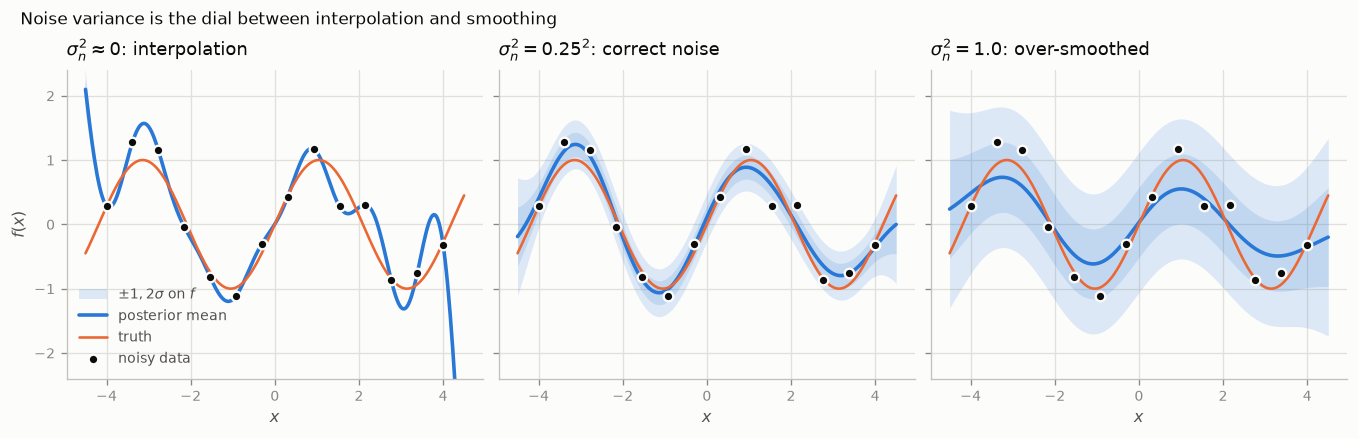

sigma_n^2 = 1e-10     RMSE against the TRUE function = 0.8279
sigma_n^2 = 0.0625    RMSE against the TRUE function = 0.1468
sigma_n^2 = 1         RMSE against the TRUE function = 0.3157


In [30]:
x_ns = np.linspace(-4, 4, 14)
y_clean = f_demo(x_ns)
y_noisy = y_clean + 0.25 * np.random.default_rng(11).standard_normal(len(x_ns))
Xg = x_gr.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.6), sharey=True, constrained_layout=True)
for ax, nv, ttl in zip(axes, [1e-10, 0.25**2, 1.0],
                       [r"$\sigma_n^2 \approx 0$: interpolation",
                        r"$\sigma_n^2 = 0.25^2$: correct noise",
                        r"$\sigma_n^2 = 1.0$: over-smoothed"]):
    g = GP(RBF(1.0, 1.0), noise_var=nv, fit_noise=False).fit(x_ns.reshape(-1,1), y_noisy)
    m_, s_ = g.predict(Xg)
    band(ax, x_gr, m_, s_, C1, label=r"$\pm1,2\sigma$ on $f$")
    ax.plot(x_gr, m_, color=C1, lw=2.2, label="posterior mean")
    ax.plot(x_gr, f_demo(x_gr), color=C2, lw=1.6, label="truth")
    dots(ax, x_ns, y_noisy, INK, label="noisy data")
    ax.set(xlabel="$x$", ylim=(-2.4, 2.4), title=ttl)
axes[0].set_ylabel("$f(x)$")
axes[0].legend(loc="lower left")
fig.suptitle("Noise variance is the dial between interpolation and smoothing",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

for nv in [1e-10, 0.25**2, 1.0]:
    g = GP(RBF(1.0, 1.0), noise_var=nv, fit_noise=False).fit(x_ns.reshape(-1,1), y_noisy)
    m_, s_ = g.predict(Xg)
    err = np.sqrt(np.mean((m_ - f_demo(x_gr))**2))
    print(f"sigma_n^2 = {nv:<8.4g}  RMSE against the TRUE function = {err:.4f}")

Notice the left panel: with $\sigma_n^2\approx0$ the GP contorts itself to pass through every
noisy point, and the result is visibly worse than the truth — classic overfitting, and the RMSE
confirms it. The right panel throws away real signal. The middle panel, where $\sigma_n^2$
matches the actual noise, wins.

We chose that value by knowing the answer. In real life you do not. Which brings us to the
part of GP practice where the actual work happens.

---
## 6. Choosing hyperparameters: the log marginal likelihood

$\ell$, $\sigma_f^2$, $\sigma_n^2$ are **hyperparameters** — they parameterise the prior over
functions rather than the function itself. Everything about a GP's performance rides on them,
and eyeballing is not an option in 6 dimensions with 7 hyperparameters.

Two respectable approaches:

1. **Cross-validation.** Hold out data, minimise held-out error. Robust, model-agnostic,
   expensive, and awkward when $n$ is small.
2. **Maximise the marginal likelihood.** Cheap (one Cholesky per evaluation), principled, and
   the standard choice. This is what we do.

### 6.1 What "marginal" means, and why it self-regularises

The marginal likelihood is the probability of the observed data under the prior, with the
unknown function **integrated out**:

$$ p(\mathbf{y} \mid X, \theta) = \int p(\mathbf{y}\mid \mathbf{f})\, p(\mathbf{f}\mid X,\theta)\, d\mathbf{f}. $$

For a GP that integral is a Gaussian and does it analytically: $\mathbf{y}\sim\mathcal{N}(\mathbf{m}, K_\theta + \sigma_n^2 I)$. Writing $K_y = K_\theta + \sigma_n^2 I$ and $\mathbf{r} = \mathbf{y}-\mathbf{m}$,

$$
\boxed{\;\log p(\mathbf{y}\mid X,\theta) =
\underbrace{-\tfrac12 \mathbf{r}^\top K_y^{-1}\mathbf{r}}_{\text{data fit}}
\;\underbrace{-\tfrac12 \log|K_y|}_{\text{complexity penalty}}
\;\underbrace{-\tfrac{n}{2}\log 2\pi}_{\text{constant}}\;}
$$

This is **not** the same as the fit quality, and the difference is the whole point:

- The **data-fit** term rewards explaining the data. It is maximised by a flexible prior —
  short $\ell$, large $\sigma_f^2$.
- The **complexity penalty** $-\tfrac12\log|K_y|$ punishes exactly that. A flexible prior
  spreads probability over a huge space of functions, so any *particular* dataset gets little
  of it. $\log|K_y|$ grows as the prior admits more functions.

The sum is an automatic Occam's razor. Nothing was held out; no regularisation coefficient was
tuned. This falls out of integrating over $\mathbf{f}$ rather than optimising it — the reason
GPs resist overfitting where a maximum-likelihood fit of the same flexibility would not.

Let us look at the actual surface. We use the 14 noisy points from section 5, hold
$\sigma_n^2$ at its true value, and scan $(\ell, \sigma_f)$.

model                             ell  sigma_f       LML   RMSE vs truth
------------------------------------------------------------------------
too flexible                     0.15     1.00    -17.15           0.376
too rigid                        6.00     1.00    -54.54           0.658
marginal-likelihood optimum      0.90     0.79    -12.23           0.151


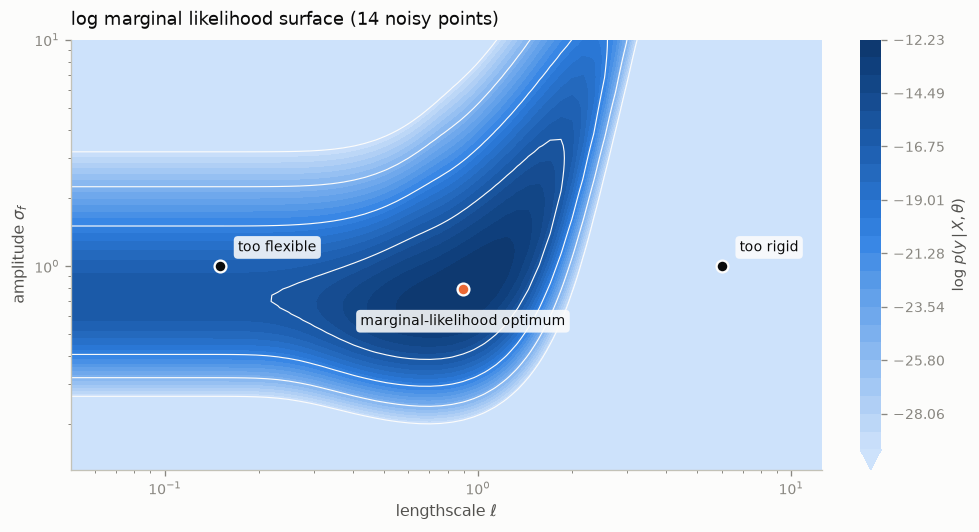

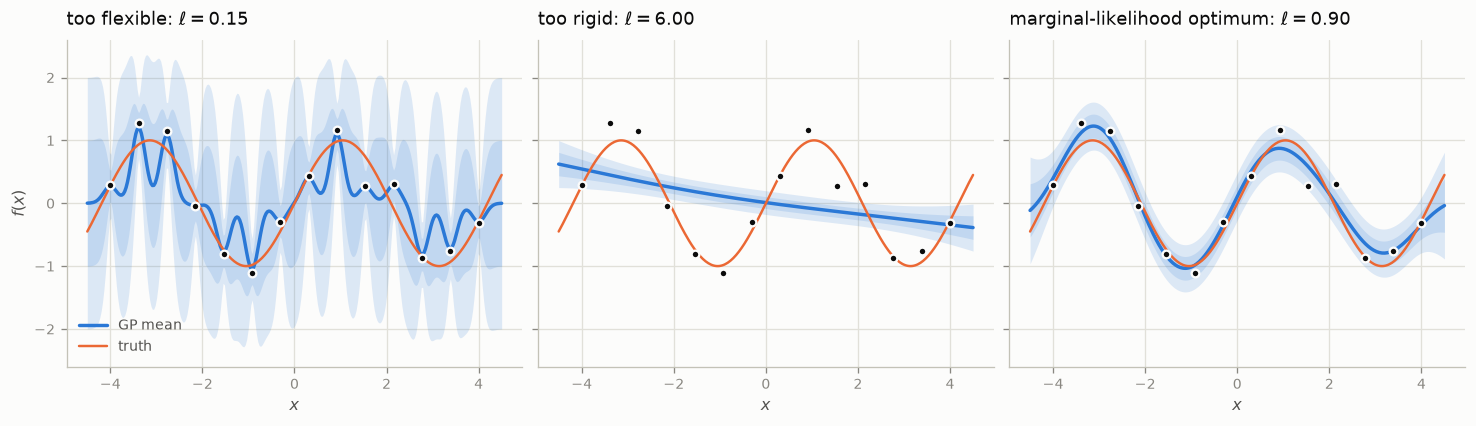

grid optimum: ell = 0.896, sigma_f = 0.792, LML = -12.232


In [31]:
Xn, yn = x_ns.reshape(-1, 1), y_noisy
ells = np.logspace(-1.3, 1.1, 70)
sfs  = np.logspace(-0.9, 1.0, 70)

gp_scan = GP(RBF(1.0, 1.0), noise_var=0.25**2, fit_noise=False).fit(Xn, yn)
LML = np.empty((len(sfs), len(ells)))
for i, sf in enumerate(sfs):
    for j, el in enumerate(ells):
        LML[i, j] = gp_scan.log_marginal_likelihood(np.log([sf**2, el]))

i_best, j_best = np.unravel_index(np.argmax(LML), LML.shape)
sf_best, ell_best = sfs[i_best], ells[j_best]
picks = [(0.15, 1.0, "too flexible"), (6.0, 1.0, "too rigid"),
         (ell_best, sf_best, "marginal-likelihood optimum")]

print(f"{'model':<30}{'ell':>7}{'sigma_f':>9}{'LML':>10}{'RMSE vs truth':>16}")
print("-" * 72)
for el, sf, name in picks:
    lml = gp_scan.log_marginal_likelihood(np.log([sf**2, el]))
    g = GP(RBF(sf**2, el), noise_var=0.25**2, fit_noise=False).fit(Xn, yn)
    m_, _ = g.predict(Xg)
    print(f"{name:<30}{el:>7.2f}{sf:>9.2f}{lml:>10.2f}"
          f"{np.sqrt(np.mean((m_-f_demo(x_gr))**2)):>16.3f}")

fig, axc = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
lv = np.linspace(np.percentile(LML, 55), LML.max(), 24)
cf = axc.contourf(ells, sfs, LML, levels=lv, cmap=BLUES, extend="min")
# linestyles="solid": matplotlib dashes contours at NEGATIVE levels by default, and LML < 0
axc.contour(ells, sfs, LML, levels=lv[::6], colors=SURF, linewidths=0.7,
            linestyles="solid")
axc.set(xscale="log", yscale="log", xlabel=r"lengthscale $\ell$",
        ylabel=r"amplitude $\sigma_f$",
        title="log marginal likelihood surface (14 noisy points)")
axc.grid(False)
cb = fig.colorbar(cf, ax=axc, fraction=0.046); cb.outline.set_visible(False)
cb.set_label("log $p(y\\,|\\,X,\\theta)$", color=INK2, fontsize=9)
for el, sf, name in picks:
    is_opt = name.startswith("marginal")
    dots(axc, [el], [sf], C2 if is_opt else INK, size=52)
    # the surface is dark in the middle, so labels carry a surface-coloured plate
    axc.annotate(name, (el, sf), textcoords="offset points",
                 xytext=(0, -22) if is_opt else (11, 9),
                 ha="center" if is_opt else "left", fontsize=8.5, color=INK, zorder=8,
                 bbox=dict(boxstyle="round,pad=0.3", fc=SURF, ec="none", alpha=0.88))
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.5), sharey=True, constrained_layout=True)
for k, (el, sf, name) in enumerate(picks):
    ax = axes[k]
    g = GP(RBF(sf**2, el), noise_var=0.25**2, fit_noise=False).fit(Xn, yn)
    m_, s_ = g.predict(Xg)
    band(ax, x_gr, m_, s_, C1, label=None)
    ax.plot(x_gr, m_, color=C1, lw=2.1)
    ax.plot(x_gr, f_demo(x_gr), color=C2, lw=1.5)
    dots(ax, x_ns, y_noisy, INK, size=22)
    ax.set(xlabel="$x$", ylim=(-2.6, 2.6), title=rf"{name}: $\ell={el:.2f}$")
    if k == 0:
        ax.set_ylabel("$f(x)$")
        ax.plot([], [], color=C1, lw=2.1, label="GP mean")
        ax.plot([], [], color=C2, lw=1.5, label="truth")
        ax.legend(loc="lower left")
plt.show()

print(f"grid optimum: ell = {ell_best:.3f}, sigma_f = {sf_best:.3f}, LML = {LML.max():.3f}")

Two things to read off. On the surface, note the long flat **ridge** running up and to the left:
many $(\ell,\sigma_f)$ combinations are nearly equally good, which is why multi-start
optimisation matters (and section 9.3 shows a case where this gets much worse).

And in the three posterior panels, look at what "too flexible" actually costs: with
$\ell = 0.15$ the GP has no reason to connect neighbouring points, so it spikes at each
observation and falls back to zero in between. It passes through the data far more closely than
the optimum does, yet its RMSE against the *truth* is about 2.5$\times$ worse. That gap between
fitting the data and recovering the function is exactly what the complexity penalty exists to
police, and the likelihood correctly scores this model far below the optimum.

Now let us see the two terms fighting, by slicing the surface at the optimal $\sigma_f$:

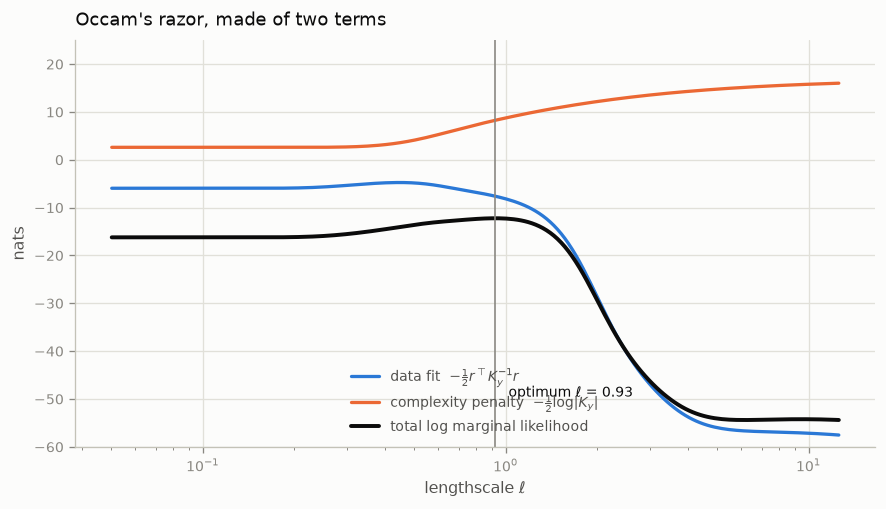

In [32]:
ells_s = np.logspace(-1.3, 1.1, 200)
fit_t, cplx_t, tot_t = [], [], []
for el in ells_s:
    g = GP(RBF(sf_best**2, el), noise_var=0.25**2, fit_noise=False).fit(Xn, yn)
    logdet = 2 * np.log(np.diag(g.L_)).sum()
    fit_t.append(-0.5 * g.resid_ @ g.alpha_)
    cplx_t.append(-0.5 * logdet)
    tot_t.append(fit_t[-1] + cplx_t[-1] - 0.5 * len(yn) * np.log(2 * np.pi))

fig, ax = plt.subplots(figsize=(7.4, 4.2), constrained_layout=True)
ax.plot(ells_s, fit_t,  color=C1, lw=2.0, label=r"data fit  $-\frac{1}{2}r^\top K_y^{-1} r$")
ax.plot(ells_s, cplx_t, color=C2, lw=2.0, label=r"complexity penalty  $-\frac{1}{2}\log|K_y|$")
ax.plot(ells_s, tot_t,  color=INK, lw=2.4, label="total log marginal likelihood")
ax.axvline(ells_s[int(np.argmax(tot_t))], color=MUTED, lw=1.0)
ax.annotate(f"optimum $\\ell$ = {ells_s[int(np.argmax(tot_t))]:.2f}",
            (ells_s[int(np.argmax(tot_t))], min(tot_t)), textcoords="offset points",
            xytext=(8, 14), fontsize=8.5, color=INK)
ax.set(xscale="log", xlabel=r"lengthscale $\ell$", ylabel="nats",
       ylim=(-60, 25), title="Occam's razor, made of two terms")
ax.legend(loc="lower center")
plt.show()

Read it left to right. At small $\ell$ the prior is very flexible: the data fit is excellent
(blue is high) but the complexity penalty is brutal (orange plunges). At large $\ell$ the prior
is rigid: the penalty relaxes but the model cannot reproduce the data. The total peaks in
between, at a value close to the true wiggle scale of $\sin(1.5x)$. **Nothing was held out.**

### 6.2 Gradients, and why they are worth the algebra

L-BFGS-B will happily estimate gradients by finite differences, but that costs one extra
likelihood evaluation — one $\mathcal{O}(n^3)$ Cholesky — *per hyperparameter per step*. The
analytic gradient costs one $\mathcal{O}(n^3)$ inverse total:

$$ \frac{\partial}{\partial \theta_j} \log p(\mathbf{y}\mid X,\theta)
= \tfrac12 \operatorname{tr}\!\left[\Big(\boldsymbol{\alpha}\boldsymbol{\alpha}^\top - K_y^{-1}\Big)
\frac{\partial K_y}{\partial \theta_j}\right],
\qquad \boldsymbol{\alpha} = K_y^{-1}\mathbf{r}. $$

For our log-parameterised SE kernel the derivative matrices are pleasantly simple:

$$ \frac{\partial K}{\partial \log \sigma_f^2} = K, \qquad
\frac{\partial K}{\partial \log \ell_i} = K \odot \frac{(x_i - x_i')^2}{\ell_i^2}, \qquad
\frac{\partial K_y}{\partial \log \sigma_n^2} = \sigma_n^2 I, $$

with $\odot$ the elementwise product. (Also, note the trace trick used in the code:
$\operatorname{tr}(W\,\partial K)=\sum_{ij}W_{ij}\,\partial K_{ij}$ for symmetric matrices —
never build the matrix product just to take its trace.)

This is the kind of derivation you have to redo by hand every time you invent a new kernel or
add a mean function, and it is exactly what automatic differentiation abolishes. Section 10
does it in JAX with `jax.grad`. First, verify our hand-derived version:

In [33]:
gp_g = GP(RBF(1.0, 1.0), noise_var=0.04, fit_noise=True).fit(Xn, yn)
theta0 = np.log([1.7, 0.8, 0.05])          # [variance, lengthscale, noise variance]

lml0, grad_analytic = gp_g.log_marginal_likelihood(theta0, eval_gradient=True)

eps = 1e-6
grad_fd = np.array([
    (gp_g.log_marginal_likelihood(theta0 + eps*np.eye(3)[i])
     - gp_g.log_marginal_likelihood(theta0 - eps*np.eye(3)[i])) / (2*eps)
    for i in range(3)])

print(f"LML at theta0 = {lml0:.6f}\n")
print(f"{'parameter':<22}{'analytic':>14}{'finite diff':>14}{'rel. error':>13}")
for nm, a, f in zip(["log variance", "log lengthscale", "log noise variance"],
                    grad_analytic, grad_fd):
    print(f"{nm:<22}{a:>14.7f}{f:>14.7f}{abs((a-f)/f):>13.2e}")
assert np.allclose(grad_analytic, grad_fd, rtol=1e-5), "gradient mismatch!"
print("\nanalytic gradient verified against central finite differences")

LML at theta0 = -14.677270

parameter                   analytic   finite diff   rel. error
log variance              -3.3434286    -3.3434286     1.75e-09
log lengthscale            4.5669984     4.5669984     1.44e-09
log noise variance         0.9252463     0.9252463     1.05e-09

analytic gradient verified against central finite differences


before: RBF(var=1, ell=[1.]) noise_var=0.1, LML=-12.510
  19 starts -> 2 distinct optima; best LML = -12.1507
 after: RBF(var=0.605, ell=[0.925]) noise_var=0.07862, LML=-12.151

recovered noise sd = 0.280  (true value was 0.250)
recovered lengthscale = 0.925  (sin(1.5x) turns over on a scale ~ 1/1.5 = 0.67)


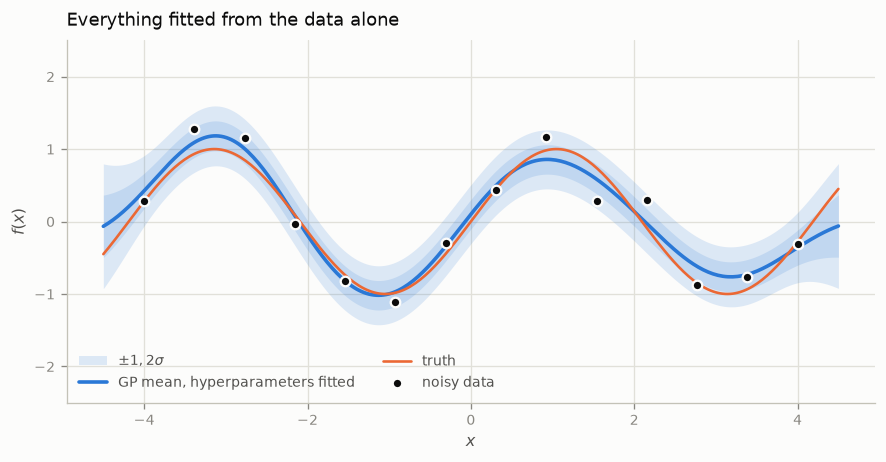

In [34]:
# ---- fit the hyperparameters for real
gp_fit = GP(RBF(1.0, 1.0), noise_var=0.1, fit_noise=True,
            noise_bounds=(1e-8, 1e2)).fit(Xn, yn)
print("before:", gp_fit.kernel, f"noise_var={gp_fit.noise_var:.4g}, "
      f"LML={gp_fit.log_marginal_likelihood():.3f}")
gp_fit.optimize(n_random=12, seed=1, verbose=True)
print(" after:", gp_fit.kernel, f"noise_var={gp_fit.noise_var:.4g}, "
      f"LML={gp_fit.log_marginal_likelihood():.3f}")
print(f"\nrecovered noise sd = {np.sqrt(gp_fit.noise_var):.3f}  (true value was 0.250)")
print(f"recovered lengthscale = {gp_fit.kernel.lengthscale[0]:.3f}  "
      f"(sin(1.5x) turns over on a scale ~ 1/1.5 = 0.67)")

m_, s_ = gp_fit.predict(Xg)
fig, ax = plt.subplots(figsize=(7.4, 3.8), constrained_layout=True)
band(ax, x_gr, m_, s_, C1, label=r"$\pm1,2\sigma$")
ax.plot(x_gr, m_, color=C1, lw=2.2, label="GP mean, hyperparameters fitted")
ax.plot(x_gr, f_demo(x_gr), color=C2, lw=1.6, label="truth")
dots(ax, x_ns, y_noisy, INK, label="noisy data")
ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-2.5, 2.5),
       title="Everything fitted from the data alone")
ax.legend(loc="lower left", ncol=2)
plt.show()

### 6.3 Five things that will bite you

1. **The likelihood is not convex.** Multiple local optima are normal, and they often
   correspond to genuinely different interpretations of the data ("smooth function + big
   noise" vs. "wiggly function + small noise"). *Always* use multiple restarts — `optimize`
   above reports how many distinct optima it landed in. Section 9 shows a case with more than
   twenty.
2. **Optimise in log space, always.** Scale parameters span orders of magnitude; log space
   enforces positivity and conditions the problem.
3. **Watch for parameters pinned at their bounds.** A lengthscale stuck at its ceiling or a
   $\sigma_f$ at $10^8$ is a *diagnostic*, not a result: usually your kernel cannot represent
   the data and the optimiser is trying to fake it with a degenerate limit. We will see exactly
   this in section 9.
4. **Standardise your inputs and outputs first.** Fitting $y\sim10^{-10}$ or $x\sim10^{3}$
   pushes hyperparameters to numerical extremes for no reason. Section 9 does this properly.
5. **Bound the lengthscale below, at roughly the training-point spacing.** This one is subtle
   and costs people real time. As $\ell\to0$ the SE kernel becomes a delta function —
   *indistinguishable from white noise*. The optimiser will happily drive $\ell$ to zero and
   explain your observation noise with the signal kernel instead of $\sigma_n^2$. Everything
   still looks fine on a plot, but the fitted noise level is meaningless and the predictive
   error bars are inflated. Below the point spacing the lengthscale is simply not identifiable,
   so bound it there. There is a mirror-image degeneracy at the top end: as $\ell\to\infty$ the
   kernel becomes constant, which is unidentifiable against a constant term in the mean
   function (section 8) — two hyperparameters, one flat direction.

---
## 7. The kernel zoo

The SE kernel is the default, and it is often the wrong default: it assumes the function is
*infinitely* differentiable, which is a strong claim. Here is the working set.

| Kernel | Form | Use when |
|---|---|---|
| **Squared exponential** | $\sigma_f^2\exp(-r^2/2\ell^2)$ | very smooth, analytic response |
| **Matérn 5/2** | $\sigma_f^2(1+\sqrt5 r_\ell+\tfrac53 r_\ell^2)e^{-\sqrt5 r_\ell}$ | the sane default: twice differentiable |
| **Matérn 3/2** | $\sigma_f^2(1+\sqrt3 r_\ell)e^{-\sqrt3 r_\ell}$ | once differentiable, visibly rougher |
| **Matérn 1/2 (exponential)** | $\sigma_f^2 e^{-r_\ell}$ | continuous but nowhere differentiable |
| **Periodic** | $\sigma_f^2\exp(-2\sin^2(\pi r/p)/\ell^2)$ | exactly repeating structure |
| **Linear** | $\sigma_f^2\, x\!\cdot\!x' + c$ | a global trend (degenerate — see below) |

with $r=|x-x'|$ and $r_\ell = r/\ell$. The Matérn family interpolates between exponential and
SE via a smoothness index $\nu$; sample paths are $\lceil\nu\rceil-1$ times differentiable, and
$\nu\to\infty$ recovers the SE kernel.

**Combine them.** Sums and products of valid kernels are valid:

- $k_1 + k_2$ — "the function is a **sum** of two independent behaviours." Long-lengthscale
  plus short-lengthscale gives trend-plus-wiggles, which is exactly the structure of our test
  function in section 9.
- $k_1 \times k_2$ — "the behaviours **modulate** each other." SE $\times$ Periodic gives
  *locally* periodic: repeating, but slowly drifting in shape.

A note on **Linear**, since it behaves unlike the others: it is a *degenerate* kernel of rank
$d+1$, so its sample paths are exactly straight lines with no residual freedom. This is worth
knowing because it is the bridge to section 8 — an explicit parametric mean function is
mathematically the same thing as adding a degenerate kernel.

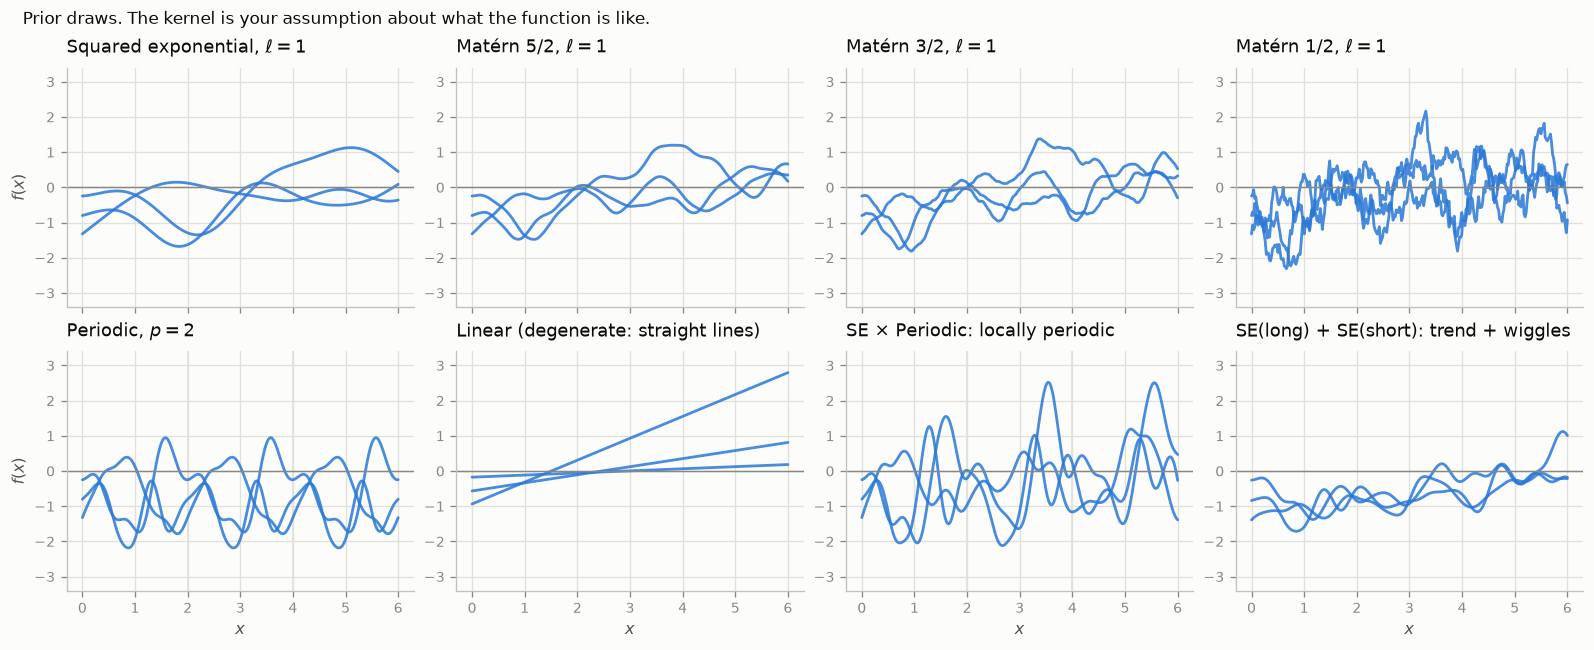

In [35]:
def prior_draws(x, kobj, n=4, seed=5):
    '''Prior samples using the jittered Cholesky (needed for degenerate kernels).'''
    X = x.reshape(-1, 1)
    L, _ = cholesky_jittered(kobj(X, X), 1e-10)
    return (L @ np.random.default_rng(seed).standard_normal((len(x), n))).T

xz = np.linspace(0, 6, 300)
PER = 2.0
zoo = [
    ("Squared exponential, $\\ell=1$",     RBF(1.0, 1.0),            None),
    ("Matérn 5/2, $\\ell=1$",              Matern(2.5, 1.0, 1.0),    None),
    ("Matérn 3/2, $\\ell=1$",              Matern(1.5, 1.0, 1.0),    None),
    ("Matérn 1/2, $\\ell=1$",              Matern(0.5, 1.0, 1.0),    None),
    (f"Periodic, $p={PER:.0f}$",           Periodic(1.0, 1.0, PER),  PER),
    ("Linear (degenerate: straight lines)", Linear(0.3, 0.5),         None),
    ("SE $\\times$ Periodic: locally periodic",
     RBF(1.0, 3.0) * Periodic(1.0, 0.8, PER), PER),
    ("SE(long) + SE(short): trend + wiggles", RBF(1.0, 3.0) + RBF(0.1, 0.25), None),
]
fig, axes = plt.subplots(2, 4, figsize=(13.4, 5.4), sharex=True, constrained_layout=True)
for ax, (name, kobj, per) in zip(axes.ravel(), zoo):
    if per:                       # mark the period so the repetition is legible
        for t in np.arange(per, 6.0, per):
            ax.axvline(t, color=GRID, lw=1.0, zorder=0)
    for s in prior_draws(xz, kobj, 3):
        ax.plot(xz, s, color=C1, lw=1.7, alpha=0.85)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set(title=name, ylim=(-3.4, 3.4))
for ax in axes[1]: ax.set_xlabel("$x$")
for ax in axes[:, 0]: ax.set_ylabel("$f(x)$")
fig.suptitle("Prior draws. The kernel is your assumption about what the function is like.",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

Compare the top row carefully: all four have $\ell = 1$ and $\sigma_f = 1$, so they roam the
same vertical range on the same horizontal scale, yet SE draws are silky while Matérn 1/2 draws
are jagged fractal noise. **Smoothness is a separate assumption from lengthscale**, and it is
the one people forget to think about.

### Does the marginal likelihood pick the right kernel?

Fair test: generate ground truth by *drawing a sample from a Matérn 3/2 prior*, so we know the
true smoothness class. Then fit all four kernels, letting each optimise its own
hyperparameters, and compare marginal likelihood against genuine held-out error.

kernel               LML   held-out RMSE   fitted ell   fitted sn
-----------------------------------------------------------------
SE                  9.51          0.1082        0.267    1.38e-02
Matérn 5/2         15.70          0.0902        0.449    7.38e-03
Matérn 3/2         16.70          0.0888        0.676    2.98e-05
Matérn 1/2          1.79          0.1106        2.102    1.00e-05

best by marginal likelihood: Matérn 3/2
best by held-out RMSE      : Matérn 3/2
truth was drawn from       : Matérn 3/2


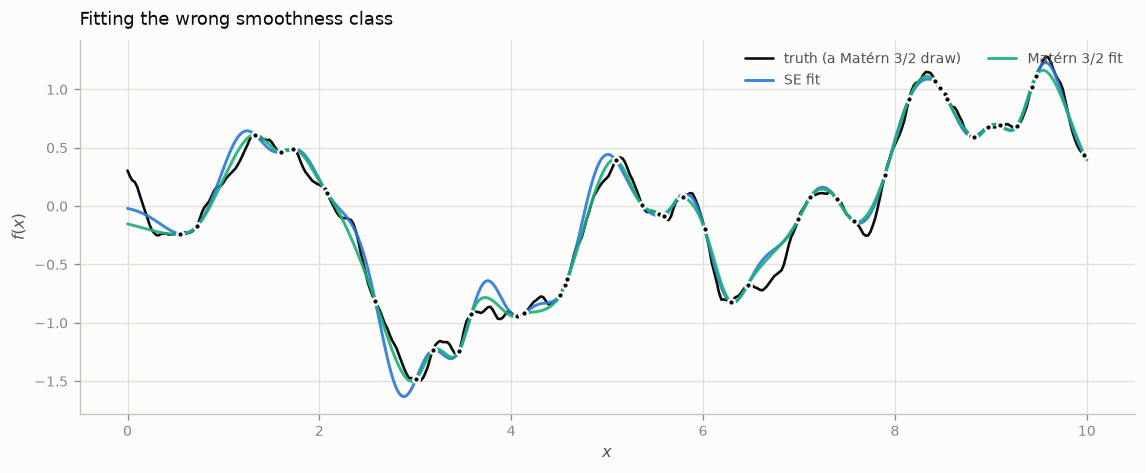

In [36]:
xg_k = np.linspace(0, 10, 400)
Xg_k = xg_k.reshape(-1, 1)
k_true = Matern(1.5, 1.0, 0.9)
f_true_k = prior_draws(xg_k, k_true, 1, seed=42)[0]          # one fixed realisation

rng_k = np.random.default_rng(4)
idx_tr = np.sort(rng_k.choice(len(xg_k), 45, replace=False))
mask_te = np.ones(len(xg_k), bool); mask_te[idx_tr] = False
Xtr_k, ytr_k = Xg_k[idx_tr], f_true_k[idx_tr]

cands = [("SE",          RBF(1.0, 1.0)),
         ("Matérn 5/2",  Matern(2.5, 1.0, 1.0)),
         ("Matérn 3/2",  Matern(1.5, 1.0, 1.0)),
         ("Matérn 1/2",  Matern(0.5, 1.0, 1.0))]

print(f"{'kernel':<14}{'LML':>10}{'held-out RMSE':>16}{'fitted ell':>13}{'fitted sn':>12}")
print("-" * 65)
results_k = []
for name, kobj in cands:
    g = GP(kobj, noise_var=1e-6, fit_noise=True,
           noise_bounds=(1e-10, 1e0)).fit(Xtr_k, ytr_k)
    g.optimize(n_random=8, seed=2)
    m_, _ = g.predict(Xg_k)
    rmse = np.sqrt(np.mean((m_[mask_te] - f_true_k[mask_te])**2))
    lml = g.log_marginal_likelihood()
    results_k.append((name, lml, rmse, m_))
    print(f"{name:<14}{lml:>10.2f}{rmse:>16.4f}{g.kernel.lengthscale[0]:>13.3f}"
          f"{np.sqrt(g.noise_var):>12.2e}")

best_lml = max(results_k, key=lambda r: r[1])[0]
best_rmse = min(results_k, key=lambda r: r[2])[0]
print(f"\nbest by marginal likelihood: {best_lml}")
print(f"best by held-out RMSE      : {best_rmse}")
print(f"truth was drawn from       : Matérn 3/2")

fig, ax = plt.subplots(figsize=(9.6, 3.9), constrained_layout=True)
ax.plot(xg_k, f_true_k, color=INK, lw=1.6, label="truth (a Matérn 3/2 draw)")
for (name, lml, rmse, m_), col in zip(results_k, [C1, C2, C3]):
    if name in ("SE", "Matérn 1/2", "Matérn 3/2"):
        ax.plot(xg_k, m_, color=col, lw=1.8, alpha=0.9, label=f"{name} fit")
dots(ax, Xtr_k.ravel(), ytr_k, INK, size=16)
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Fitting the wrong smoothness class")
ax.legend(loc="upper right", ncol=2)
plt.show()

The marginal likelihood and the held-out error agree, and both prefer the kernel the data
actually came from. This is the standard workflow: **treat the kernel choice as a discrete
model-selection problem and compare marginal likelihoods.** One caveat — that comparison is
only valid when the likelihoods use the same convention and the same mean structure, a point
that matters in a moment when we introduce basis functions.

---
## 8. Mean functions: why GPs cannot extrapolate, and what to do

Return to the very first posterior plot. Outside the data, the mean went to zero and the band
opened to $\pm2\sigma_f$. That is not a bug. It is what
$\boldsymbol{\mu}_* = \sum_i\alpha_i k(x_i,x_*)$ *must* do when $k$ decays: once
$|x_* - x_i| \gg \ell$ for every training point, every kernel value is $\approx 0$ and the
prediction is the prior mean.

**A stationary GP does not extrapolate. It reverts.** Watch how fast:

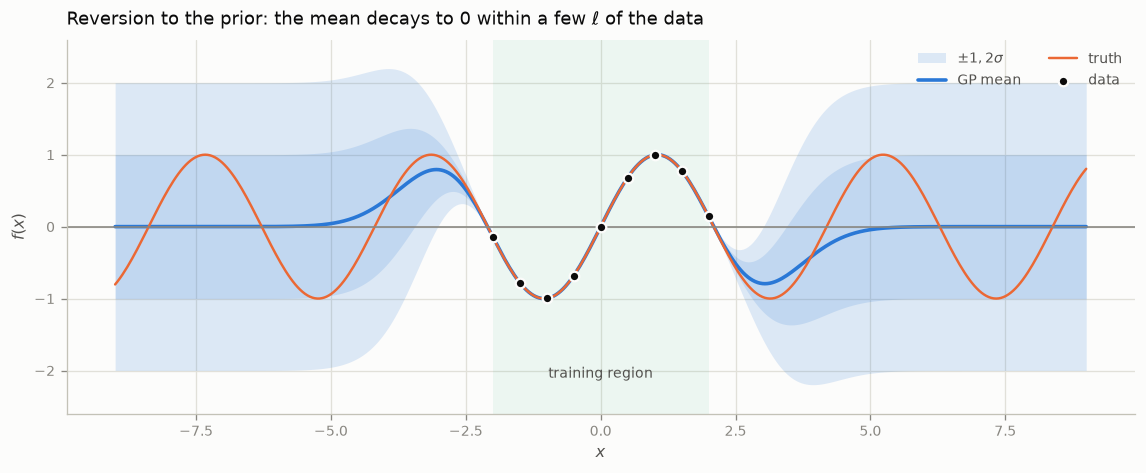

x =  2.5:  GP mean = -0.5187,  sd = 0.103,  truth = -0.5716
x =  3.5:  GP mean = -0.6543,  sd = 0.711,  truth = -0.8589
x =  5.0:  GP mean = -0.0439,  sd = 0.999,  truth = +0.9380
x =  8.0:  GP mean = -0.0000,  sd = 1.000,  truth = -0.5366


In [37]:
x_lo = np.linspace(-2, 2, 9); y_lo = f_demo(x_lo)
x_wide = np.linspace(-9, 9, 400)

g_rev = GP(RBF(1.0, 1.0), noise_var=1e-8, fit_noise=False).fit(x_lo.reshape(-1,1), y_lo)
m_r, s_r = g_rev.predict(x_wide.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(9.6, 3.9), constrained_layout=True)
band(ax, x_wide, m_r, s_r, C1, label=r"$\pm1,2\sigma$")
ax.plot(x_wide, m_r, color=C1, lw=2.2, label="GP mean")
ax.plot(x_wide, f_demo(x_wide), color=C2, lw=1.5, label="truth")
ax.axhline(0, color=MUTED, lw=1.0)
ax.axvspan(-2, 2, color=C3, alpha=0.07, lw=0)
ax.annotate("training region", (0, -2.1), ha="center", fontsize=8.5, color=INK2)
dots(ax, x_lo, y_lo, INK, label="data")
ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-2.6, 2.6),
       title=r"Reversion to the prior: the mean decays to 0 within a few $\ell$ of the data")
ax.legend(loc="upper right", ncol=2)
plt.show()

for xq in [2.5, 3.5, 5.0, 8.0]:
    i = np.argmin(abs(x_wide - xq))
    print(f"x = {xq:>4.1f}:  GP mean = {m_r[i]:+.4f},  sd = {s_r[i]:.3f},  "
          f"truth = {f_demo(xq):+.4f}")

Two comforting facts and one warning. Comforting: the reversion is *honest* — by $x=5$ the sd
has grown to essentially the full prior width, so the GP is loudly announcing that it does not
know. And the truth stays inside the band. The warning: that honesty is guaranteed only when
the kernel is a reasonable description of the function. In section 9 we will find a case where
the mean is badly wrong **and** the band fails to cover.

### 8.1 Giving the GP a mean function

If you know something about the global shape — a power law, a polynomial trend, a physical
limit — put it in the mean and let the GP model only the residual. Write the mean as a linear
combination of $p$ basis functions,

$$ m(x) = \mathbf{h}(x)^\top\boldsymbol{\beta}, \qquad
H = \big[\mathbf{h}(x_1),\dots,\mathbf{h}(x_n)\big]^\top \in \mathbb{R}^{n\times p}. $$

You could fix $\boldsymbol{\beta}$ by least squares first and hand the residuals to the GP, but
that double-counts: the detrending uncertainty gets forgotten. The better route takes
$\boldsymbol{\beta}$ to have a *vague* (infinitely broad) prior and integrates it out
analytically. The result — known as **universal kriging**, or a GP with explicit basis
functions — is:

$$
\begin{aligned}
\hat{\boldsymbol{\beta}} &= \big(H^\top K_y^{-1} H\big)^{-1} H^\top K_y^{-1}\mathbf{y}
&&\text{(generalised least squares)}\\[3pt]
\boldsymbol{\mu}_* &= H_*\hat{\boldsymbol{\beta}} + K_*^\top K_y^{-1}\big(\mathbf{y}-H\hat{\boldsymbol{\beta}}\big) \\[3pt]
\Sigma_* &= \underbrace{K_{**} - K_*^\top K_y^{-1}K_*}_{\text{usual GP term}}
 + \underbrace{R^\top\big(H^\top K_y^{-1}H\big)^{-1}R}_{\text{uncertainty in }\hat{\boldsymbol{\beta}}},
 \qquad R = H_*^\top - H^\top K_y^{-1}K_*.
\end{aligned}
$$

The third line is the part worth appreciating: an **extra** variance contribution that
accounts for not knowing the trend coefficients. It is small inside the data and grows as you
extrapolate — precisely where you need it. This is already implemented in our `GP` via the
`basis=` argument.

The matching marginal likelihood (a REML-type expression, up to a $\theta$-independent
constant) is

$$ \log p(\mathbf{y}\mid X,\theta) = -\tfrac12\mathbf{r}^\top K_y^{-1}\mathbf{r}
-\tfrac12\log|K_y| - \tfrac12\log\big|H^\top K_y^{-1} H\big| - \tfrac{n-p}{2}\log 2\pi. $$

Because the normalisation depends on $p$ and we dropped a constant, **compare different bases
by held-out error, not by these numbers.** Comparing kernels at fixed basis is fine.

mean function             extrap. RMSE (|x|>3)   2-sigma coverage           fitted beta
---------------------------------------------------------------------------------------
zero mean                                3.941                0%                     -
constant mean [1]                        3.941                0%                  [0.]
linear mean [1,x]                        0.718              100%         [0.    0.705]


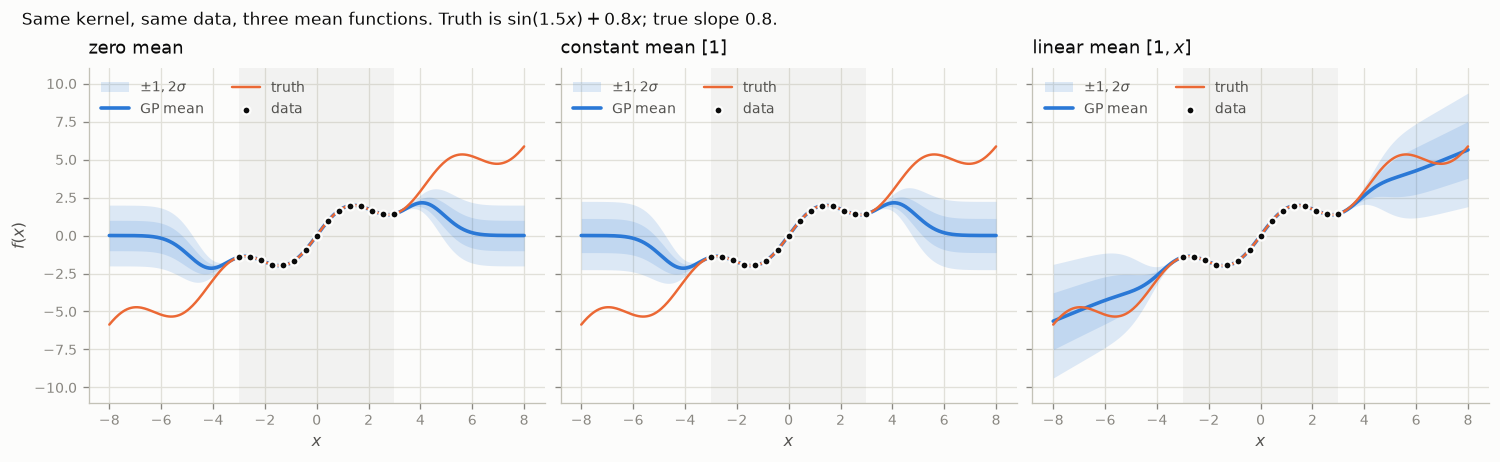

In [38]:
# a function with a genuine global trend
f_trend = lambda t: np.sin(1.5 * t) + 0.8 * t
x_t = np.linspace(-3, 3, 15); y_t = f_trend(x_t)
x_mf = np.linspace(-8, 8, 400); Xmf = x_mf.reshape(-1, 1)
out_mf = np.abs(x_mf) > 3

# NOTE: hyperparameters are held FIXED at sensible values here, deliberately, so that the
# only thing changing across the three panels is the mean function. Left free, the optimiser
# inflates sigma_f until the kernel itself absorbs the trend and the comparison is muddied --
# a pathology we diagnose properly in section 9.3.
# small multiples: the SAME encoding in every panel (blue = GP mean, orange = truth,
# as everywhere else in this notebook). The panel title carries the identity.
configs = [("zero mean",          None,                                          C1),
           ("constant mean $[1]$", lambda X: np.ones((len(np.atleast_2d(X)), 1)), C1),
           ("linear mean $[1,x]$", lambda X: np.c_[np.ones(len(np.atleast_2d(X))),
                                                   np.atleast_2d(X)[:, 0]],      C1)]

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.8), sharey=True, constrained_layout=True)
print(f"{'mean function':<24}{'extrap. RMSE (|x|>3)':>22}{'2-sigma coverage':>19}"
      f"{'fitted beta':>22}")
print("-" * 87)
for ax, (name, bas, col) in zip(axes, configs):
    g = GP(RBF(1.0, 1.0), noise_var=1e-8, fit_noise=False,
           basis=bas).fit(x_t.reshape(-1, 1), y_t)
    m_, s_ = g.predict(Xmf)
    rmse = np.sqrt(np.mean((m_[out_mf] - f_trend(x_mf[out_mf]))**2))
    cov2 = np.mean(np.abs(m_[out_mf] - f_trend(x_mf[out_mf])) < 2*s_[out_mf])
    bstr = "-" if g.beta_ is None else np.array2string(g.beta_, precision=3)
    plain = name.replace("$", "").replace("\\", "")
    print(f"{plain:<24}{rmse:>22.3f}{cov2:>18.0%}{bstr:>22}")

    band(ax, x_mf, m_, s_, col, label=r"$\pm1,2\sigma$")
    ax.plot(x_mf, m_, color=col, lw=2.2, label="GP mean")
    ax.plot(x_mf, f_trend(x_mf), color=C2, lw=1.5, label="truth")
    dots(ax, x_t, y_t, INK, size=24, label="data")
    ax.axvspan(-3, 3, color=MUTED, alpha=0.08, lw=0)
    ax.set(xlabel="$x$", ylim=(-11, 11), title=name)
    ax.legend(loc="upper left", ncol=2)
axes[0].set_ylabel("$f(x)$")
fig.suptitle(r"Same kernel, same data, three mean functions. Truth is $\sin(1.5x)+0.8x$;"
             r" true slope 0.8.", fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

The numbers tell the story: the linear mean cuts the extrapolation error by a factor of ~5 and
repairs the coverage from **0% to 100%**, and its fitted slope $\hat\beta_1\approx0.7$ recovers
the true $0.8$ from data spanning only $[-3,3]$.

Two details worth noticing:

- **The constant mean does nothing here** — it scores identically to the zero mean, because
  $\sin(1.5x)+0.8x$ is antisymmetric on a symmetric design, so the best-fitting constant *is*
  zero. A mean function only helps if it can represent the structure that is actually there.
- **The zero-mean band does not cover the truth at all** (0%), while the linear-mean band does
  everywhere. The extra $R^\top(H^\top K_y^{-1}H)^{-1}R$ term is doing real work: the
  linear-mean band widens as you extrapolate because $\hat{\boldsymbol\beta}$ is uncertain, and
  that widening is what makes the uncertainty honest.

### 8.2 An explicit mean *is* a degenerate kernel

Worth internalising, because it demystifies the formulas above. Putting a Gaussian prior
$\boldsymbol{\beta}\sim\mathcal{N}(0,\sigma_\beta^2 I)$ on the coefficients of
$m(x)=\mathbf{h}(x)^\top\boldsymbol{\beta}$ adds a term
$\sigma_\beta^2\,\mathbf{h}(x)^\top\mathbf{h}(x')$ to the covariance. So a "mean function" is
just extra kernel structure, and the vague-prior universal-kriging equations are the
$\sigma_\beta^2\to\infty$ limit of an ordinary zero-mean GP. Let us confirm that numerically —
a good check that the implementation is right.

In [39]:
Xt, Xs_ = x_t.reshape(-1, 1), np.linspace(-7, 7, 60).reshape(-1, 1)
bas_lin = lambda X: np.c_[np.ones(len(np.atleast_2d(X))), np.atleast_2d(X)[:, 0]]
NV = 1e-6                                     # same noise level in both formulations

# route A: the universal-kriging equations (vague prior on beta, integrated out)
g_uk = GP(RBF(1.0, 1.0), noise_var=NV, fit_noise=False, basis=bas_lin).fit(Xt, y_t)
mu_uk, sd_uk = g_uk.predict(Xs_)

# route B: a plain ZERO-MEAN GP whose kernel gains the degenerate term sb2 * h(x).h(x')
kern_rbf = RBF(1.0, 1.0)
H, Hs = bas_lin(Xt), bas_lin(Xs_)
print(f"{'sigma_beta^2':>14}{'max |mean diff|':>18}{'max |sd diff|':>16}")
print("-" * 48)
for sb2 in [1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e8]:
    Kb   = kern_rbf(Xt, Xt) + sb2 * (H @ H.T) + NV * np.eye(len(Xt))
    Ksb  = kern_rbf(Xt, Xs_) + sb2 * (H @ Hs.T)
    kssb = kern_rbf.diag(Xs_) + sb2 * (Hs * Hs).sum(1)
    Lb = np.linalg.cholesky(Kb)
    mu_b = Ksb.T @ cho_solve((Lb, True), y_t)
    v_b = solve_triangular(Lb, Ksb, lower=True)
    sd_b = np.sqrt(np.clip(kssb - (v_b**2).sum(0), 0, None))
    print(f"{sb2:>14.0e}{np.abs(mu_b-mu_uk).max():>18.2e}{np.abs(sd_b-sd_uk).max():>16.2e}")

  sigma_beta^2   max |mean diff|   max |sd diff|
------------------------------------------------
         1e+01          1.75e-02        3.87e-03
         1e+02          1.76e-03        3.93e-04
         1e+03          1.70e-04        4.04e-05
         1e+04          1.19e-05        5.12e-06
         1e+05          9.19e-07        8.67e-07
         1e+06          4.85e-05        2.61e-05
         1e+08          3.22e-03        2.32e-03


Both columns fall by a clean factor of 10 for every factor of 10 in $\sigma_\beta^2$ — the
$\mathcal{O}(1/\sigma_\beta^2)$ convergence you would predict — confirming that the
universal-kriging equations really are the $\sigma_\beta^2\to\infty$ limit of an ordinary
zero-mean GP, and that our implementation of them is correct.

Then past $\sigma_\beta^2\approx10^5$ the agreement stops improving and *reverses*. That is not a
failure of the theory but of the arithmetic: $\sigma_\beta^2\,H H^\top$ now swamps the kernel by
several orders of magnitude and the Cholesky loses precision. Which is precisely why the
closed-form vague-prior equations are worth having, rather than "just use a huge prior variance."

---
## 9. The test: $y(x) = x^3 + 0.1\sin(2x)$

Time to stress the machinery on a function chosen to be awkward in a realistic way. On
$x\in[-3,3]$:

$$ y(x) = \underbrace{x^3}_{\text{range} \pm 27} \;+\; \underbrace{0.1\sin(2x)}_{\text{amplitude } 0.1} $$

Why this is a good test rather than a toy:

- **A huge non-stationary trend.** $x^3$ has a strong global shape. A stationary kernel assumes
  the function looks statistically the same everywhere, which this does not.
- **A tiny high-frequency feature riding on it.** The ripple's amplitude is $0.1$ against a
  signal whose RMS over the domain is $10.2$ — so the ripple is **about 1% of the signal**, and
  a peak-to-peak $0.2$ against a range of $54$ is under 0.4% of the dynamic range. That makes
  the arithmetic pleasingly direct: *an emulator that misses the ripple entirely sits at roughly
  1% error.* Recovering it is the same problem as hitting a 1% target on a CMB spectrum — you
  need accuracy in a **relative** sense, not a plot that looks right.
- **The scales are entangled.** The ripple has period $\pi\approx3.14$ while the cubic turns
  over on a scale of a few units. There is no clean frequency separation to exploit.
- **We know the answer**, so every claim about accuracy is checkable.

### 9.1 First: standardise

Fitting this raw is asking for trouble — $y$ spans $\pm27$, so the GP would have to discover
$\sigma_f \sim 10$, and the basis functions in section 8 would have columns of wildly different
magnitude. Standard practice, and what every emulator paper does:

$$ \tilde{x} = \frac{x - \bar{x}}{\mathrm{sd}(x)}, \qquad \tilde{y} = \frac{y-\bar{y}}{\mathrm{sd}(y)} $$

Fit in tilde-space with $\mathcal{O}(1)$ hyperparameters, then map predictions back. Note that
the predictive *standard deviation* transforms with a plain factor $\mathrm{sd}(y)$.

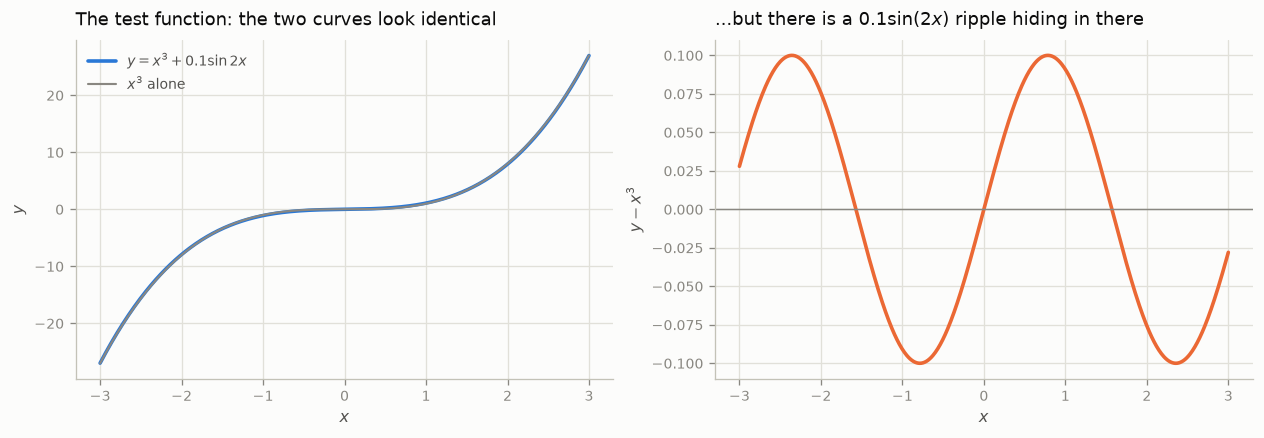

signal RMS over [-3,3]      = 10.215
ripple amplitude            = 0.100  (0.98% of the signal RMS)
1% of signal RMS            = 0.1022   <-- the accuracy bar to beat


In [40]:
f_test = lambda t: t**3 + 0.1 * np.sin(2 * t)

class StandardizedGP:
    '''
    Wraps GP with z-scoring of inputs and outputs. Hyperparameters and any `basis`
    callable then live in standardised space, where everything is O(1).
    '''
    def __init__(self, kernel, basis=None, **gp_kw):
        self.gp = GP(kernel, basis=basis, **gp_kw)

    def fit(self, X, y, optimize=True, **opt_kw):
        X = np.atleast_2d(np.asarray(X, float)); y = np.asarray(y, float).ravel()
        self.xm_, self.xs_ = X.mean(0), X.std(0)
        self.ym_, self.ys_ = y.mean(), y.std()
        self.gp.fit((X - self.xm_) / self.xs_, (y - self.ym_) / self.ys_)
        if optimize:
            self.gp.optimize(**opt_kw)
        return self

    def predict(self, Xs, return_std=True):
        Xs = np.atleast_2d(np.asarray(Xs, float))
        out = self.gp.predict((Xs - self.xm_) / self.xs_, return_std=return_std)
        if not return_std:
            return out * self.ys_ + self.ym_
        mu, sd = out
        return mu * self.ys_ + self.ym_, sd * self.ys_

    @property
    def kernel(self):     return self.gp.kernel
    @property
    def noise_var(self):  return self.gp.noise_var
    def log_marginal_likelihood(self): return self.gp.log_marginal_likelihood()

x_plot = np.linspace(-3, 3, 600)
X_plot = x_plot.reshape(-1, 1)
sig_rms = np.sqrt(np.mean(f_test(x_plot)**2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 3.6), constrained_layout=True)
a1.plot(x_plot, f_test(x_plot), color=C1, lw=2.2, label=r"$y = x^3 + 0.1\sin 2x$")
a1.plot(x_plot, x_plot**3, color=MUTED, lw=1.3, label=r"$x^3$ alone")
a1.set(xlabel="$x$", ylabel="$y$", title="The test function: the two curves look identical")
a1.legend(loc="upper left")

a2.plot(x_plot, 0.1*np.sin(2*x_plot), color=C2, lw=2.2)
a2.axhline(0, color=MUTED, lw=0.9)
a2.set(xlabel="$x$", ylabel=r"$y - x^3$",
       title=r"...but there is a $0.1\sin(2x)$ ripple hiding in there")
plt.show()

print(f"signal RMS over [-3,3]      = {sig_rms:.3f}")
print(f"ripple amplitude            = 0.100  ({0.1/sig_rms:.2%} of the signal RMS)")
print(f"1% of signal RMS            = {0.01*sig_rms:.4f}   <-- the accuracy bar to beat")

### 9.2 Interpolation: how many training points do we need?

Noise-free (the simulator is deterministic), zero mean function, plain SE kernel, everything
fitted by marginal likelihood.

   N        RMSE   max |err|   max err / RMS  fitted sigma_f  fitted ell
--------------------------------------------------------------------------
   8    6.65e-03    1.84e-02         0.180%            9.48       1.828
  20    2.29e-04    6.72e-04         0.007%           10.28       1.454
  40    1.70e-04    4.34e-04         0.004%            6.67       1.370


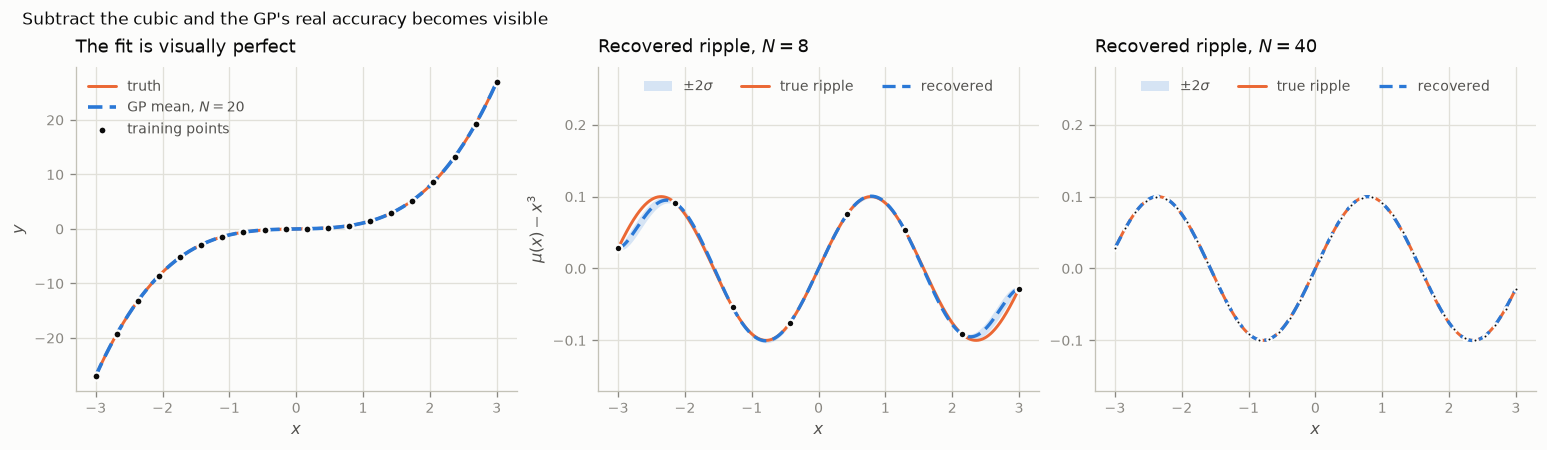

In [41]:
def run_interp(N, seed=0):
    xtr = np.linspace(-3, 3, N)
    m = StandardizedGP(RBF(1.0, 1.0), noise_var=1e-8, fit_noise=True,
                       noise_bounds=(1e-12, 1e-4), jitter=1e-10)
    m.fit(xtr.reshape(-1, 1), f_test(xtr), n_random=10, seed=seed)
    mu, sd = m.predict(X_plot)
    return xtr, m, mu, sd

runs = {N: run_interp(N) for N in (8, 20, 40)}

print(f"{'N':>4}{'RMSE':>12}{'max |err|':>12}{'max err / RMS':>16}"
      f"{'fitted sigma_f':>16}{'fitted ell':>12}")
print("-" * 74)
for N, (xtr, m, mu, sd) in runs.items():
    err = mu - f_test(x_plot)
    print(f"{N:>4}{np.sqrt(np.mean(err**2)):>12.2e}{np.abs(err).max():>12.2e}"
          f"{np.abs(err).max()/sig_rms:>15.3%}"
          f"{np.sqrt(m.kernel.variance):>16.2f}{m.kernel.lengthscale[0]:>12.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.7), constrained_layout=True)

axes[0].plot(x_plot, f_test(x_plot), color=C2, lw=1.8, label="truth")
xtr, m, mu, sd = runs[20]
axes[0].plot(x_plot, mu, color=C1, lw=2.2, ls=(0, (4, 2)), label="GP mean, $N=20$")
dots(axes[0], xtr, f_test(xtr), INK, size=24, label="training points")
axes[0].set(xlabel="$x$", ylabel="$y$", title="The fit is visually perfect")
axes[0].legend(loc="upper left")

for ax, N in zip(axes[1:], (8, 40)):
    xtr, m, mu, sd = runs[N]
    ripple_hat = mu - x_plot**3
    ax.fill_between(x_plot, ripple_hat - 2*sd, ripple_hat + 2*sd,
                    color=C1, alpha=0.18, lw=0, label=r"$\pm2\sigma$")
    ax.plot(x_plot, 0.1*np.sin(2*x_plot), color=C2, lw=1.8, label=r"true ripple")
    ax.plot(x_plot, ripple_hat, color=C1, lw=2.0, ls=(0, (4, 2)), label="recovered")
    dots(ax, xtr, f_test(xtr) - xtr**3, INK, size=22 if N <= 20 else 7)
    ax.set(xlabel="$x$", ylim=(-0.17, 0.28), title=f"Recovered ripple, $N={N}$")
    ax.legend(loc="upper center", ncol=3)
axes[1].set_ylabel(r"$\mu(x) - x^3$")
fig.suptitle("Subtract the cubic and the GP's real accuracy becomes visible",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

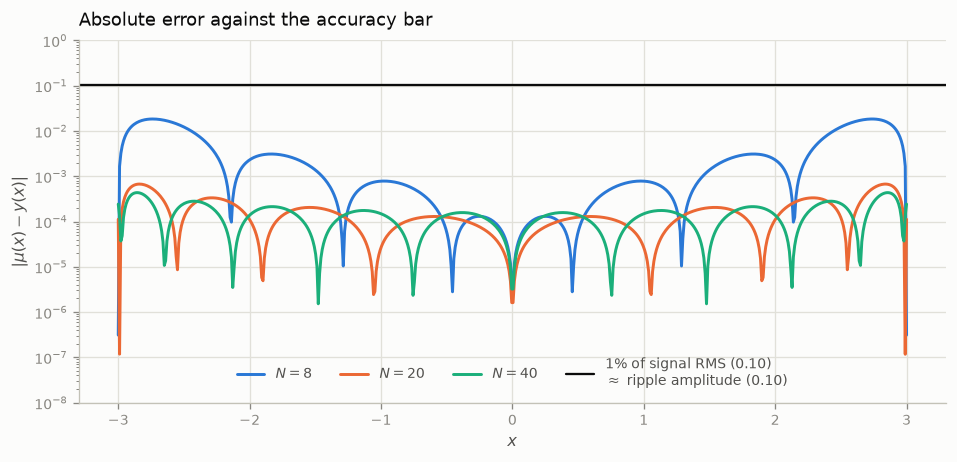

In [42]:
fig, ax = plt.subplots(figsize=(8.0, 3.8), constrained_layout=True)
for (N, (xtr, m, mu, sd)), col in zip(runs.items(), [C1, C2, C3]):
    ax.semilogy(x_plot, np.abs(mu - f_test(x_plot)) + 1e-16, color=col, lw=1.8,
                label=f"$N = {N}$")
# the ripple amplitude (0.100) and 1% of the signal RMS (0.102) coincide to within 2% --
# that is the whole point of this test function, so draw ONE line and say so
ax.axhline(0.01 * sig_rms, color=INK, lw=1.4,
           label=f"1% of signal RMS ({0.01*sig_rms:.2f})\n$\\approx$ ripple amplitude (0.10)")
ax.set(xlabel="$x$", ylabel=r"$|\mu(x) - y(x)|$", ylim=(1e-8, 1e0),
       title="Absolute error against the accuracy bar")
ax.legend(loc="lower center", ncol=4)
plt.show()

Results worth pausing on:

- Even **$N=8$** points clears the 1% bar comfortably and recovers the shape of the ripple —
  the very feature that *defines* that bar — though you can see it under-shoots the amplitude
  slightly, and the $\pm2\sigma$ band correctly widens between points.
- **$N=40$** nails it: the recovered ripple lies on top of the truth, with error four orders of
  magnitude below the ripple amplitude.
- The error is largest **at the domain edges**, which is generic: edge points have neighbours on
  one side only. Real emulator designs should over-sample the boundary of the parameter space.
- Errors spike *between* training points and collapse to $\sim10^{-8}$ at them — visible as the
  scalloping in the log-scale figure. That is exact interpolation at work.

### 9.3 A warning sign in the fitted hyperparameters

Look again at the fitted $\sigma_f$ in the table above. After standardisation the data has
variance 1, yet the GP chose $\sigma_f$ of order **seven to ten**. It is claiming the function
roams over $\pm 7$–$10$ standard deviations of its own observed range. That is not a description
of the data; it is a symptom.

What is happening: an SE kernel in the limit of large $\sigma_f$ and long $\ell$ becomes
locally *polynomial-like* — expand $\exp(-r^2/2\ell^2)$ for $r\ll\ell$ and you get a
polynomial in $r^2$. The optimiser has discovered it can mimic a cubic trend by pushing the SE
kernel into this degenerate corner. It works, in-sample, but it means the likelihood surface has
a long flat ridge instead of a well-defined peak.

Ill-conditioned model, ill-conditioned optimisation. Let us count the local optima:

In [43]:
xtr40 = np.linspace(-3, 3, 40)
sgp_zero = StandardizedGP(RBF(1.0, 1.0), noise_var=1e-8, fit_noise=True,
                          noise_bounds=(1e-12, 1e-4))
sgp_zero.fit(xtr40.reshape(-1, 1), f_test(xtr40), n_random=20, seed=3)
funs = np.array([r.fun for r in sgp_zero.gp.opt_results_])
print("zero-mean SE kernel on the cubic")
print(f"  starts that converged   : {len(funs)}")
print(f"  distinct optima (3 dp)  : {len(np.unique(np.round(funs, 3)))}")
print(f"  best five -LML          : {np.sort(funs)[:5].round(3)}")
print(f"  fitted sigma_f          : {np.sqrt(sgp_zero.kernel.variance):.2f}"
      f"   (data sd is 1.0 after standardising)")
print(f"  fitted ell              : {sgp_zero.kernel.lengthscale[0]:.3f}")

zero-mean SE kernel on the cubic
  starts that converged   : 27
  distinct optima (3 dp)  : 15
  best five -LML          : [-254.66  -249.198 -248.188 -247.049 -243.754]
  fitted sigma_f          : 3.21   (data sd is 1.0 after standardising)
  fitted ell              : 1.037


More than a dozen distinct local optima from 27 starts, with the best few only a few nats apart.
And notice something else: this fit reports $\sigma_f\approx3$ while the $N=40$ row of the table
above — *the same data* — reported $\sigma_f\approx7$. The two runs differ only in their random
restarts. When two fits of identical data disagree by a factor of two on a hyperparameter while
scoring almost the same likelihood, the likelihood has a flat ridge and the parameters are not
identified.

**A flat, multimodal likelihood plus an implausibly large amplitude is how misspecification
announces itself.** It is worth checking every time you fit a GP, and it is why `optimize`
reports the spread of optima rather than silently returning the best one.

### 9.4 Extrapolation, and a genuine failure of the error bars

Now the real test. Train on $[-3,3]$, predict on $[-6,6]$.

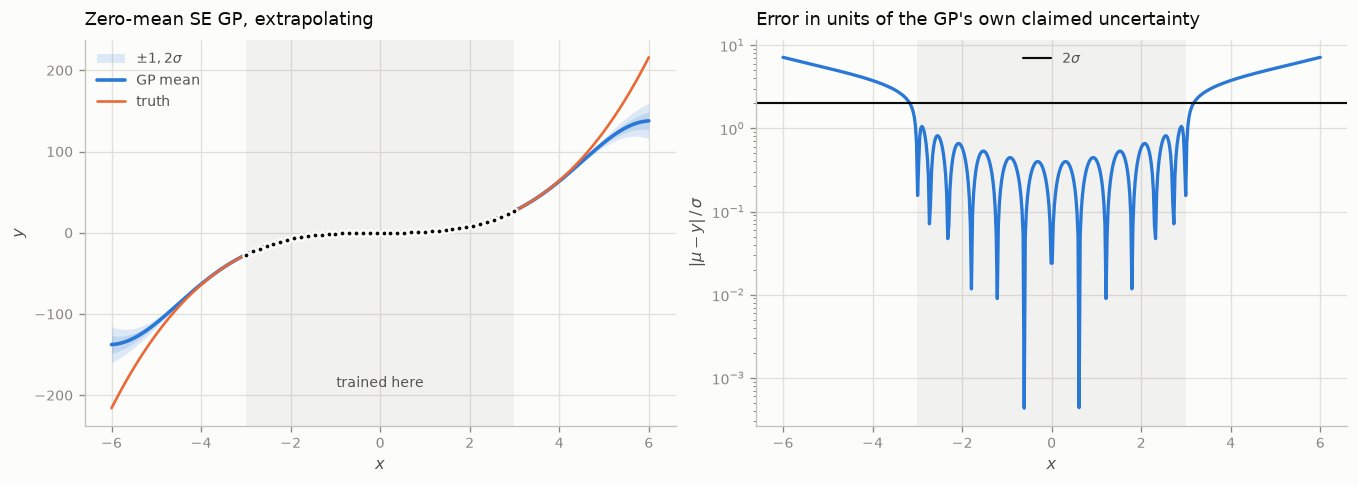

     x       truth     GP mean     GP sd      |z|
-------------------------------------------------
   3.0       26.81       26.81      0.00      0.2
   3.5       42.90       42.84      0.02      2.9
   4.0       64.29       63.54      0.20      3.8
   5.0      124.20      110.64      2.57      5.3
   6.0      215.95      137.70     10.95      7.1

fraction of extrapolation region inside 2 sigma: 6%


In [44]:
x_ext = np.linspace(-6, 6, 500); X_ext = x_ext.reshape(-1, 1)
mu_e, sd_e = sgp_zero.predict(X_ext)
truth_e = f_test(x_ext)
out = np.abs(x_ext) > 3

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.0), constrained_layout=True)
band(a1, x_ext, mu_e, sd_e, C1, label=r"$\pm1,2\sigma$")
a1.plot(x_ext, mu_e, color=C1, lw=2.2, label="GP mean")
a1.plot(x_ext, truth_e, color=C2, lw=1.6, label="truth")
a1.axvspan(-3, 3, color=MUTED, alpha=0.09, lw=0)
a1.annotate("trained here", (0, -190), ha="center", fontsize=8.5, color=INK2)
dots(a1, xtr40, f_test(xtr40), INK, size=14)
a1.set(xlabel="$x$", ylabel="$y$", title="Zero-mean SE GP, extrapolating")
a1.legend(loc="upper left")

z = (mu_e - truth_e) / sd_e
a2.plot(x_ext, np.abs(z), color=C1, lw=2.0)
a2.axhline(2, color=INK, lw=1.3, label=r"$2\sigma$")
a2.axvspan(-3, 3, color=MUTED, alpha=0.09, lw=0)
a2.set(xlabel="$x$", ylabel=r"$|\mu - y| \,/\, \sigma$", yscale="log",
       title="Error in units of the GP's own claimed uncertainty")
a2.legend(loc="upper center")
plt.show()

print(f"{'x':>6}{'truth':>12}{'GP mean':>12}{'GP sd':>10}{'|z|':>9}")
print("-" * 49)
for xq in [3.0, 3.5, 4.0, 5.0, 6.0]:
    i = np.argmin(abs(x_ext - xq))
    print(f"{xq:>6.1f}{truth_e[i]:>12.2f}{mu_e[i]:>12.2f}{sd_e[i]:>10.2f}"
          f"{abs(z[i]):>9.1f}")
print(f"\nfraction of extrapolation region inside 2 sigma: "
      f"{np.mean(np.abs(z[out]) < 2):.0%}")

This is the most important figure in the notebook, so let us be precise about what it shows.

The mean degrades gracefully at first — the large-$\sigma_f$, long-$\ell$ regime the optimiser
found does behave a bit like a polynomial, so modest extrapolation is not catastrophic. But the
right-hand panel is the real story: **the error measured in units of the GP's own predictive
standard deviation grows without bound.** The error bars widen, but nowhere near fast enough.
The GP is not merely wrong; it is *confidently* wrong, and it does not warn you.

This is the single most important caveat about GP uncertainties, and it is why "the GP told me
its error bar" is not a substitute for held-out validation:

> A GP's predictive variance is the correct uncertainty **conditional on the kernel and mean
> being right**. It quantifies ignorance about the function's *values*, never about the
> *model*. Misspecify the model and you get wrong predictions with confident error bars.

Section 8's reversion demo *did* keep the truth inside the band — because there the kernel was
a fair description of $\sin(1.5x)$. Here it is not, and the guarantee evaporates.

### 9.5 The fix: put the physics in the mean function

We know the function has a cubic trend. Give the GP that basis,
$\mathbf{h}(x) = [1, x, x^2, x^3]$, and let it model only what is left over. In standardised
coordinates a cubic in $\tilde{x}$ spans the same space as a cubic in $x$, so this is
well-conditioned.

mean function                interp RMSE   extrap RMSE   max |z| extrap   sigma_f     ell
-----------------------------------------------------------------------------------------
zero mean                       1.70e-04      1.34e+01              4.7     6.666   1.370
constant $[1]$                  2.09e-04      1.52e+01              4.1     7.193   1.343
linear $[1,x]$                  3.27e-05      2.76e+01              8.2     0.999   0.754
cubic $[1,x,x^2,x^3]$           5.67e-07      1.19e-01              1.0     0.014   0.731
quintic $[1..x^5]$              9.77e-07      5.40e-01              0.8     0.258   1.151


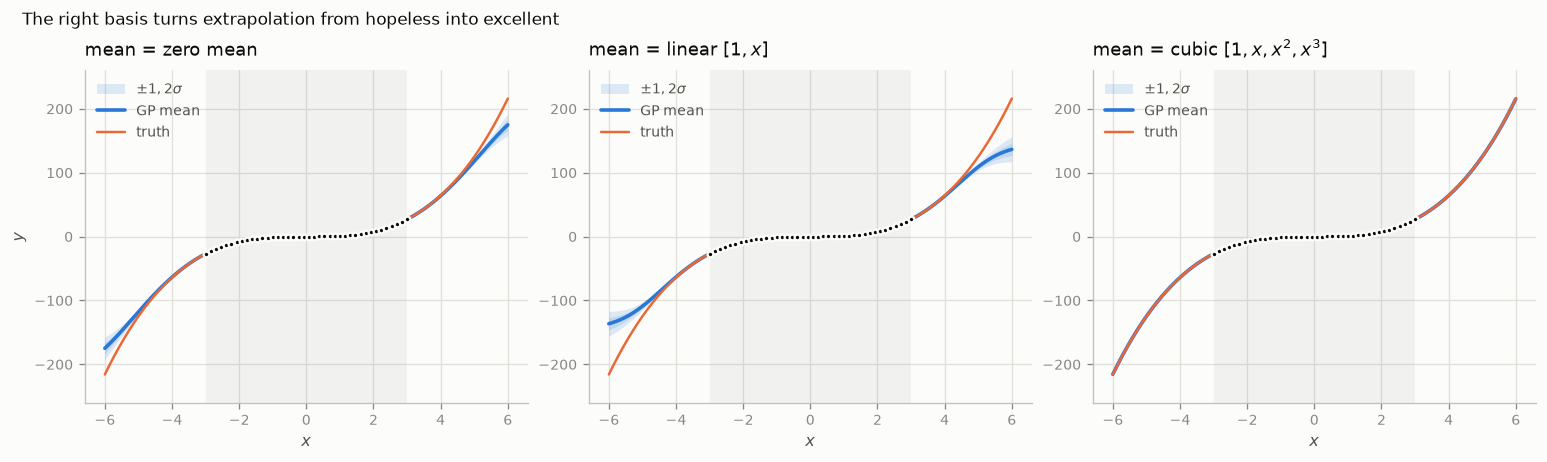

In [45]:
def poly_basis(p):
    return lambda X: np.vstack([np.atleast_2d(X)[:, 0]**k for k in range(p + 1)]).T

ytr40 = f_test(xtr40)
print(f"{'mean function':<26}{'interp RMSE':>14}{'extrap RMSE':>14}"
      f"{'max |z| extrap':>17}{'sigma_f':>10}{'ell':>8}")
print("-" * 89)

fits = {}
for name, bas in [("zero mean", None), ("constant $[1]$", poly_basis(0)),
                  ("linear $[1,x]$", poly_basis(1)),
                  ("cubic $[1,x,x^2,x^3]$", poly_basis(3)),
                  ("quintic $[1..x^5]$", poly_basis(5))]:
    m = StandardizedGP(RBF(1.0, 1.0), basis=bas, noise_var=1e-8, fit_noise=True,
                       noise_bounds=(1e-12, 1e-4))
    m.fit(xtr40.reshape(-1, 1), ytr40, n_random=10, seed=5)
    mu, sd = m.predict(X_ext)
    zz = np.abs(mu - truth_e) / sd
    fits[name] = (m, mu, sd)
    print(f"{name:<26}{np.sqrt(np.mean((mu-truth_e)[~out]**2)):>14.2e}"
          f"{np.sqrt(np.mean((mu-truth_e)[out]**2)):>14.2e}{zz[out].max():>17.1f}"
          f"{np.sqrt(m.kernel.variance):>10.3f}{m.kernel.lengthscale[0]:>8.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8), constrained_layout=True)
for ax, name in zip(axes, ["zero mean", "linear $[1,x]$", "cubic $[1,x,x^2,x^3]$"]):
    m, mu, sd = fits[name]
    band(ax, x_ext, mu, sd, C1, label=r"$\pm1,2\sigma$")
    ax.plot(x_ext, mu, color=C1, lw=2.2, label="GP mean")
    ax.plot(x_ext, truth_e, color=C2, lw=1.5, label="truth")
    ax.axvspan(-3, 3, color=MUTED, alpha=0.09, lw=0)
    dots(ax, xtr40, ytr40, INK, size=12)
    ax.set(xlabel="$x$", ylim=(-260, 260), title=f"mean = {name}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("$y$")
fig.suptitle("The right basis turns extrapolation from hopeless into excellent",
             fontsize=10.5, color=INK, x=0.01, ha="left")
plt.show()

With the cubic basis, the GP now only has to model the ripple:
  fitted sigma_f (standardised units) : 0.0136
  ripple amplitude in those units     : 0.0091
  fitted ell                          : 0.731
  distinct optima (3 dp)              : 10   (zero-mean model had 15)
  best five -LML                      : [-387.966 -382.431 -357.039 -338.76  -333.713]


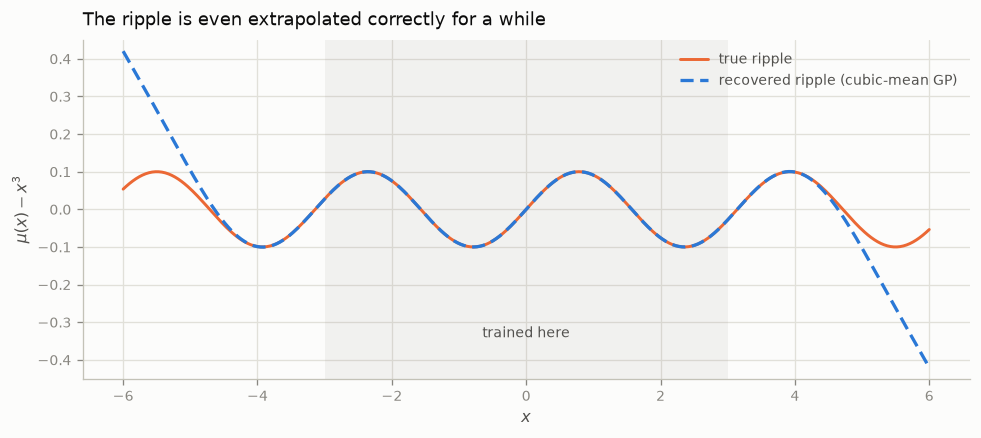

In [46]:
m_cub = fits["cubic $[1,x,x^2,x^3]$"][0]
print("With the cubic basis, the GP now only has to model the ripple:")
print(f"  fitted sigma_f (standardised units) : {np.sqrt(m_cub.kernel.variance):.4f}")
print(f"  ripple amplitude in those units     : {0.1/np.std(ytr40):.4f}")
print(f"  fitted ell                          : {m_cub.kernel.lengthscale[0]:.3f}")
funs_c = np.array([r.fun for r in m_cub.gp.opt_results_])
print(f"  distinct optima (3 dp)              : {len(np.unique(np.round(funs_c, 3)))}"
      f"   (zero-mean model had {len(np.unique(np.round(funs, 3)))})")
print(f"  best five -LML                      : {np.sort(funs_c)[:5].round(3)}")

fig, ax = plt.subplots(figsize=(8.2, 3.6), constrained_layout=True)
mu_c = fits["cubic $[1,x,x^2,x^3]$"][1]
ax.plot(x_ext, 0.1*np.sin(2*x_ext), color=C2, lw=1.8, label="true ripple")
ax.plot(x_ext, mu_c - x_ext**3, color=C1, lw=2.0, ls=(0, (4, 2)),
        label="recovered ripple (cubic-mean GP)")
ax.axvspan(-3, 3, color=MUTED, alpha=0.09, lw=0)
ax.annotate("trained here", (0, -0.34), ha="center", fontsize=8.5, color=INK2)
ax.set(xlabel="$x$", ylabel=r"$\mu(x) - x^3$", ylim=(-0.45, 0.45),
       title="The ripple is even extrapolated correctly for a while")
ax.legend(loc="upper right")
plt.show()

The cubic basis wins on every axis at once: interpolation error improves by a factor of ~300,
extrapolation error by a factor of ~100, and — most importantly — the worst extrapolated z-score
falls from ~5 to ~1, meaning **the error bars have become trustworthy again.**

And the fitted hyperparameters now describe something real. The amplitude has collapsed from
several (in standardised units, where the data's own sd is 1) to $\sigma_f\approx0.014$, which is
essentially the ripple's own size, $0.1/\mathrm{sd}(y)\approx0.009$. The lengthscale is the
ripple's scale. The model has stopped pretending to be a cubic and now says something true:
*cubic trend, plus one small smooth wiggle.*

Two warnings this table also delivers:

- **The wrong structure can be worse than none.** The linear basis extrapolates *worse* than the
  zero mean (RMSE 28 vs 13). Fitting a straight line to something that curves like $x^3$ commits
  the model to the wrong asymptotic behaviour, and it pays for that outside the data.
- **More basis functions is not better.** The quintic basis loses to the cubic on both
  interpolation and extrapolation. Extra columns you have no physical reason to believe just add
  variance. **Use the basis your physics justifies, not the largest one you can write down.**

Multi-start is still essential, by the way — even the cubic model has several local optima. What
changed is that the best one is now a sharply identified, physically sensible description rather
than a point on a flat ridge.

The transferable lesson for emulator building:

> **Structure beats data.** Adding $32$ more training points improved the interpolation error
> by about an order of magnitude. Adding the *right mean function* improved extrapolation by
> nearly two, made the hyperparameter fit identifiable, and shrank the model to something
> interpretable. If you know your observable has a known asymptotic form or a leading-order
> scaling, factor it out before handing the residual to the GP. This is exactly why CMB
> emulators work with $\log C_\ell$, or normalise by a fiducial spectrum, rather than
> emulating $C_\ell$ raw.

### 9.6 Validating the uncertainties, not just the mean

For an emulator that will feed an MCMC, calibration is as important as accuracy: if the GP says
$\pm\sigma$, the truth should fall within $\pm\sigma$ about 68% of the time. The diagnostic is
the standardised residual (z-score)

$$ z_i = \frac{\mu(x_i) - y(x_i)}{\sigma(x_i)}, $$

which should look like a draw from $\mathcal{N}(0,1)$ — on a held-out set drawn the same way as
the training set. Here we use a random test set inside the training domain (the honest test for
an interpolating emulator) and add a little noise so there is something to be calibrated
*about*.

Two setup choices matter, and both are the pitfalls from section 6.3 in action:

- **We validate predictions of a new noisy observation**, not of the latent function, so the
  predictive sd is $\sqrt{\operatorname{Var}[f_*] + \sigma_n^2}$ — the section 5 distinction,
  now load-bearing. (Against the latent function the residual here would be dominated by the
  ripple the GP cannot resolve, which is a *systematic* error, and z-scores would not be
  standard normal by construction.)
- **We floor the lengthscale at 0.05**, a little under the standardised training-point spacing.
  Without it the optimiser drives $\ell\to0$, the SE kernel degenerates into white noise, and it
  reports a fitted noise level 1000$\times$ too small with badly inflated error bars. Try
  removing `ls_bounds` and watch it happen.

fitted lengthscale = 1.228  (floor was 0.05, so not pinned)
recovered noise sd = 0.0513   (true 0.05)
held-out RMSE      = 0.0540
mean predicted sd  = 0.0532     <-- should track the RMSE

  interval   nominal   empirical
--------------------------------
    1sigma     68.3%       66.2%
    2sigma     95.5%       94.5%
    3sigma     99.7%       99.8%


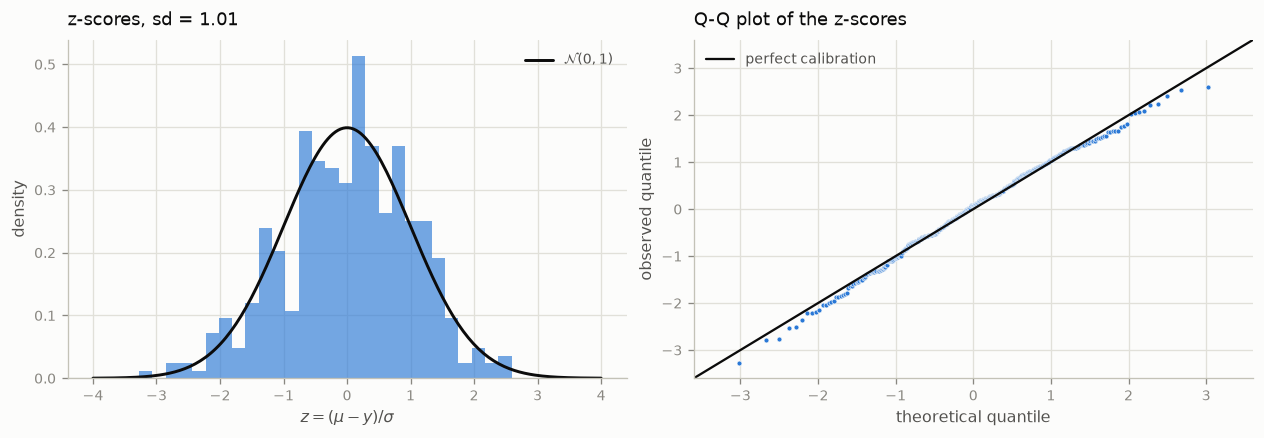

In [47]:
rng_v = np.random.default_rng(17)
noise_sd = 0.05                                  # 0.5% of signal RMS, half the ripple
xtr_v = np.sort(rng_v.uniform(-3, 3, 100))
ytr_v = f_test(xtr_v) + noise_sd * rng_v.standard_normal(len(xtr_v))
xte_v = np.sort(rng_v.uniform(-3, 3, 400))

m_v = StandardizedGP(RBF(1.0, 1.0, ls_bounds=(0.05, 1e3)), basis=poly_basis(3),
                     noise_var=1e-4, fit_noise=True, noise_bounds=(1e-10, 1e0))
m_v.fit(xtr_v.reshape(-1, 1), ytr_v, n_random=10, seed=9)

mu_v, sd_f = m_v.predict(xte_v.reshape(-1, 1))    # Var[f_*], the latent function
noise_v = np.sqrt(m_v.noise_var) * m_v.ys_        # sigma_n back in original units
sd_v = np.sqrt(sd_f**2 + noise_v**2)              # ...predicting a new OBSERVATION

yte_v = f_test(xte_v) + noise_sd * rng_v.standard_normal(len(xte_v))
z_v = (mu_v - yte_v) / sd_v

print(f"fitted lengthscale = {m_v.kernel.lengthscale[0]:.3f}  (floor was 0.05, so not pinned)")
print(f"recovered noise sd = {noise_v:.4f}   (true {noise_sd})")
print(f"held-out RMSE      = {np.sqrt(np.mean((mu_v-yte_v)**2)):.4f}")
print(f"mean predicted sd  = {sd_v.mean():.4f}     <-- should track the RMSE\n")
print(f"{'interval':>10}{'nominal':>10}{'empirical':>12}")
print("-" * 32)
for k, nom in [(1, 0.6827), (2, 0.9545), (3, 0.9973)]:
    print(f"{k}sigma".rjust(10) + f"{nom:>10.1%}{np.mean(np.abs(z_v) < k):>12.1%}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 3.6), constrained_layout=True)
a1.hist(z_v, bins=28, density=True, color=C1, alpha=0.65, lw=0)
zz = np.linspace(-4, 4, 200)
a1.plot(zz, np.exp(-zz**2/2)/np.sqrt(2*np.pi), color=INK, lw=1.8,
        label=r"$\mathcal{N}(0,1)$")
a1.set(xlabel="$z = (\\mu - y)/\\sigma$", ylabel="density",
       title=f"z-scores, sd = {z_v.std():.2f}")
a1.legend(loc="upper right")

qs = (np.arange(1, len(z_v) + 1) - 0.5) / len(z_v)
from scipy.special import erfinv
a2.plot(np.sqrt(2) * erfinv(2 * qs - 1), np.sort(z_v), color=C1, lw=0,
        marker="o", ms=3.0, mec=SURF, mew=0.4)
lim = 3.6
a2.plot([-lim, lim], [-lim, lim], color=INK, lw=1.4, label="perfect calibration")
a2.set(xlabel="theoretical quantile", ylabel="observed quantile", xlim=(-lim, lim),
       ylim=(-lim, lim), title="Q-Q plot of the z-scores")
a2.legend(loc="upper left")
plt.show()

The z-scores are close to standard normal, the empirical coverage tracks the nominal values to
within a couple of percent, the mean predicted sd matches the held-out RMSE, and the recovered
noise level lands on the truth. So **inside the training domain, with a well-specified model,
the error bars mean what they claim** — the exact opposite of the extrapolation result in
section 9.4, and a good illustration that a GP's uncertainties are trustworthy precisely where
its assumptions hold.

For a production emulator, run exactly this check, and report:

- held-out RMSE, and the **worst-case** error, not only the mean (an MCMC will find the worst
  case);
- fractional error where that is the meaningful metric;
- coverage at $1\sigma$/$2\sigma$;
- and errors sliced **per input parameter** — a mean error of 0.3% can hide a 5% failure in one
  corner of parameter space.

---
## 10. The same GP in JAX, with automatic differentiation

Everything so far was `numpy`, and we hand-derived the likelihood gradient in section 6.2. That
derivation was a page of algebra for the simplest possible case, and notice what happened when
we added basis functions in section 8: our `log_marginal_likelihood` had to raise
`NotImplementedError` for the gradient, and `optimize` silently fell back to finite differences.
Every new kernel or mean structure means another page of algebra.

**Automatic differentiation removes that entire category of work.** Write the log marginal
likelihood as a plain function — including the Cholesky, the triangular solves, and the
$\log|H^\top K_y^{-1}H|$ term — and ask JAX for its gradient. You get machine-precision
derivatives with no derivation.

Three things JAX brings beyond that:

- **`jit`** — fuses the whole likelihood into one compiled kernel, removing per-op overhead.
- **`vmap`** — vectorises over a batch. For an emulator with many outputs (say 3000 multipoles),
  this fits all of them in parallel instead of looping.
- **GPU/TPU** — the same code runs on an accelerator, where the $\mathcal{O}(n^3)$ Cholesky is
  much faster.

One essential piece of setup: **enable 64-bit before anything else.** JAX defaults to float32,
and a GP Cholesky in float32 on an ill-conditioned $K$ is hopeless. This must run before any
array is created.

In [48]:
import time
import jax
jax.config.update("jax_enable_x64", True)     # MUST come first
import jax.numpy as jnp
from jax.scipy.linalg import cho_solve as jcho_solve

print("jax", jax.__version__, "| devices:", jax.devices(),
      "| x64 enabled:", jax.config.jax_enable_x64)


def make_nll(X, y, basis=None, rel_jitter=1e-10):
    '''
    Build a JAX negative-log-marginal-likelihood for an ARD squared-exponential GP.

    theta = [log variance, log ell_1 ... log ell_d, log noise_variance]

    The jitter convention matches `cholesky_jittered` (relative to mean diag(K)),
    so results are directly comparable with the numpy implementation.
    '''
    Xj = jnp.asarray(X, dtype=jnp.float64)
    yj = jnp.asarray(np.asarray(y, float).ravel())
    n, d = Xj.shape
    Hj = None if basis is None else jnp.asarray(np.atleast_2d(basis(np.asarray(X))), float)
    p = 0 if Hj is None else Hj.shape[1]

    def nll(theta):
        var = jnp.exp(theta[0])
        ell = jnp.exp(theta[1:1 + d])
        nv  = jnp.exp(theta[1 + d])

        Z = Xj / ell
        d2 = ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1)
        K = var * jnp.exp(-0.5 * d2) + nv * jnp.eye(n)
        K = K + rel_jitter * jnp.mean(jnp.diag(K)) * jnp.eye(n)

        L = jnp.linalg.cholesky(K)
        logdetK = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))

        if Hj is None:
            a = jcho_solve((L, True), yj)
            return 0.5 * yj @ a + 0.5 * logdetK + 0.5 * n * LOG2PI

        KiH = jcho_solve((L, True), Hj)
        A = Hj.T @ KiH
        _, logdetA = jnp.linalg.slogdet(A)
        beta = jnp.linalg.solve(A, Hj.T @ jcho_solve((L, True), yj))
        r = yj - Hj @ beta
        return (0.5 * r @ jcho_solve((L, True), r) + 0.5 * logdetK
                + 0.5 * logdetA + 0.5 * (n - p) * LOG2PI)

    return nll

# the gradient we spent a page deriving is now one line
nll_demo = make_nll(Xn, yn)
grad_demo = jax.grad(nll_demo)
print("\njax.grad is ready. That was the whole derivation.")

jax 0.10.2 | devices: [CpuDevice(id=0)] | x64 enabled: True

jax.grad is ready. That was the whole derivation.


### 10.1 Verify it against the `numpy` implementation

An untested reimplementation is worthless, so check three things: the likelihood value, the
gradient, and the fitted hyperparameters — and check the gradient in the basis-function case that
we *could not* differentiate by hand.

In [49]:
theta_chk = np.log([1.7, 0.8, 0.05])
gp_chk = GP(RBF(1.0, 1.0), noise_var=0.04, fit_noise=True).fit(Xn, yn)

lml_np, grad_np = gp_chk.log_marginal_likelihood(theta_chk, eval_gradient=True)
lml_jx = float(nll_demo(jnp.asarray(theta_chk)))
grad_jx = -np.asarray(grad_demo(jnp.asarray(theta_chk)))     # nll -> lml sign flip

print("zero-mean GP, 14 points")
print(f"  LML  numpy = {lml_np:.10f}")
print(f"  LML  jax   = {-lml_jx:.10f}      diff = {abs(lml_np + lml_jx):.2e}")
print(f"  grad numpy = {grad_np}")
print(f"  grad jax   = {grad_jx}")
print(f"  max abs gradient difference = {np.abs(grad_np - grad_jx).max():.2e}")
assert np.allclose(lml_np, -lml_jx, rtol=1e-9)
assert np.allclose(grad_np, grad_jx, rtol=1e-7, atol=1e-9)

# --- the case numpy could not differentiate: the universal-kriging likelihood
Xs_v = ((xtr_v - xtr_v.mean()) / xtr_v.std()).reshape(-1, 1)
ys_v = (ytr_v - ytr_v.mean()) / ytr_v.std()
nll_bas = make_nll(Xs_v, ys_v, basis=poly_basis(3))
g_bas = jax.grad(nll_bas)

t_bas, h = np.log([0.005, 0.8, 8e-4]), 1e-5
ad = np.asarray(g_bas(jnp.asarray(t_bas)))
fd = np.array([(float(nll_bas(jnp.asarray(t_bas + h*np.eye(3)[i])))
                - float(nll_bas(jnp.asarray(t_bas - h*np.eye(3)[i])))) / (2*h)
               for i in range(3)])
print("\nuniversal-kriging likelihood (cubic basis) -- no hand derivation exists for this:")
print(f"  autodiff        = {ad}")
print(f"  finite diff     = {fd}")
print(f"  max rel. error  = {np.abs((ad - fd)/fd).max():.2e}")
assert np.abs((ad - fd)/fd).max() < 1e-6
print("\nAutodiff differentiates the Cholesky, the triangular solves and the log-determinants")
print("without being told how. That is the section 8 likelihood we could not do by hand.")

zero-mean GP, 14 points
  LML  numpy = -14.6772698724
  LML  jax   = -14.6772698724      diff = 7.11e-15
  grad numpy = [-3.3434  4.567   0.9252]
  grad jax   = [-3.3434  4.567   0.9252]
  max abs gradient difference = 3.15e-09

universal-kriging likelihood (cubic basis) -- no hand derivation exists for this:
  autodiff        = [ 1.1826 -5.8871 44.9526]
  finite diff     = [ 1.1826 -5.8871 44.9526]
  max rel. error  = 3.88e-10

Autodiff differentiates the Cholesky, the triangular solves and the log-determinants
without being told how. That is the section 8 likelihood we could not do by hand.


In [50]:
# ---- optimise with jitted value_and_grad, and compare the whole fit to numpy's
def fit_jax(X, y, basis=None, d=1, ls_bounds=(0.05, 1e3), var_bounds=(1e-8, 1e8),
            noise_bounds=(1e-10, 1e0), seed=0, n_random=10):
    nll = make_nll(X, y, basis=basis)
    vg = jax.jit(jax.value_and_grad(nll))

    def obj(t):
        v, g = vg(jnp.asarray(t))               # ONE call gives value and gradient
        return float(v), np.asarray(g, dtype=np.float64)

    bnds = ([tuple(np.log(var_bounds))] + d * [tuple(np.log(ls_bounds))]
            + [tuple(np.log(noise_bounds))])
    lo = np.array([b[0] for b in bnds]); hi = np.array([b[1] for b in bnds])
    rng = np.random.default_rng(seed)
    st = [np.clip(np.zeros(d + 2), lo, hi)] + [
        np.clip(rng.uniform([-4] + d*[-2] + [-14], [2] + d*[2] + [-1]), lo, hi)
        for _ in range(n_random)]
    res = [r for r in (minimize(obj, s, jac=True, method="L-BFGS-B", bounds=bnds)
                       for s in st) if np.isfinite(r.fun)]
    return min(res, key=lambda r: r.fun)

best_jx = fit_jax(Xs_v, ys_v, basis=poly_basis(3), d=1, seed=9)
th_np = np.log([m_v.kernel.variance, m_v.kernel.lengthscale[0], m_v.noise_var])

print(f"the 100-point problem of section 9.6 (cubic mean), refitted end-to-end\n")
print(f"{'':<8}{'LML':>16}{'variance':>14}{'ell':>12}{'noise_var':>14}")
print("-" * 64)
print(f"{'numpy':<8}{m_v.log_marginal_likelihood():>16.8f}{m_v.kernel.variance:>14.7g}"
      f"{m_v.kernel.lengthscale[0]:>12.7g}{m_v.noise_var:>14.5e}")
print(f"{'jax':<8}{-best_jx.fun:>16.8f}{np.exp(best_jx.x[0]):>14.7g}"
      f"{np.exp(best_jx.x[1]):>12.7g}{np.exp(best_jx.x[2]):>14.5e}")
print(f"\n  |LML difference|                 = {abs(m_v.log_marginal_likelihood()+best_jx.fun):.2e}")
print(f"  max |difference| in log-params   = {np.abs(best_jx.x - th_np).max():.2e}")
print("\nTwo independent implementations -- one with hand-derived numerics and")
print("finite-difference gradients, one with autodiff -- landing on the same optimum.")

the 100-point problem of section 9.6 (cubic mean), refitted end-to-end

                     LML      variance         ell     noise_var
----------------------------------------------------------------
numpy       351.38569128   0.007389492    1.228476   2.88246e-05
jax         351.38569129   0.007388693    1.228444   2.88243e-05

  |LML difference|                 = 1.16e-08
  max |difference| in log-params   = 1.08e-04

Two independent implementations -- one with hand-derived numerics and
finite-difference gradients, one with autodiff -- landing on the same optimum.


A caveat on that comparison, which is really a lesson about GPs rather than about JAX. This
particular problem is well identified, so both backends land on the same optimum. Re-run it with
the noise raised to $\sigma = 0.3$ (well above the ripple) and the two backends agree on the
*likelihood* to eight decimals while reporting **completely different hyperparameters** —
$\ell\approx90$ versus $\ell\approx900$. Neither is wrong. Once the residual is pure noise, the
long-$\ell$ limit of the kernel is constant, and a constant is exactly what the leading column
of the cubic basis already provides: the likelihood has a genuinely flat direction, and the
optimiser stops wherever it happens to be. Matching likelihoods with mismatched parameters is a
signature of a flat direction, not of a bug.

n = 800, 3 hyperparameters, one optimiser start

cost of ONE likelihood evaluation
  value only                         24.8 ms
  value + analytic gradient          96.8 ms   (forms K^-1 for the trace)
  value + autodiff gradient         109.4 ms

strategy                        evals   wall clock    LML reached
-----------------------------------------------------------------
finite differences                200       5104 ms      1235.1771
analytic (numpy)                   24       2480 ms      1235.2438
autodiff (jax, jit)                24       2258 ms      1235.2438


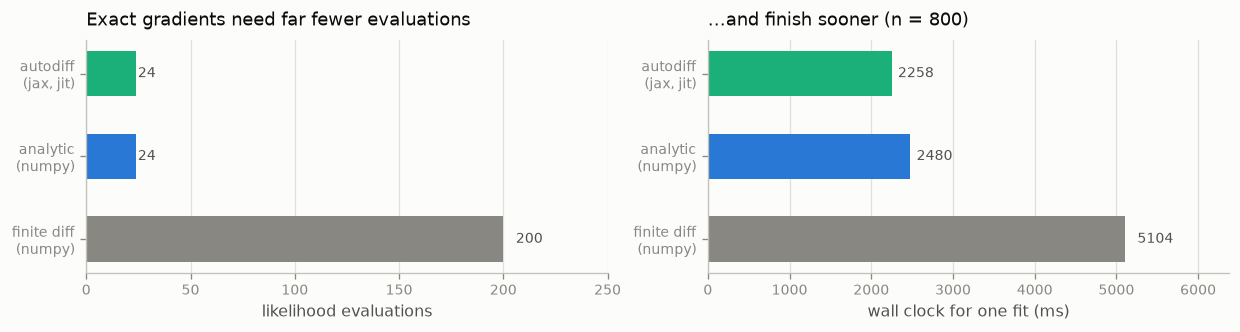

In [51]:
# ---- how much does an exact gradient actually buy you?
n_big = 800
x_big = np.linspace(-3, 3, n_big).reshape(-1, 1)
y_big = f_test(x_big.ravel()) + 0.5 * np.random.default_rng(2).standard_normal(n_big)
xb = (x_big - x_big.mean()) / x_big.std()
yb = (y_big - y_big.mean()) / y_big.std()
t_start = np.zeros(3)

def time_it(fn, repeat=7):
    fn()                                   # warm-up / compile
    ts = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))            # median: wall-clock on a shared machine is noisy

gp_big = GP(RBF(1.0, 1.0), noise_var=0.1, fit_noise=True).fit(xb, yb)
vg_big = jax.jit(jax.value_and_grad(make_nll(xb, yb)))
vg_big(jnp.asarray(t_start))               # trigger compilation

def jax_obj(t):
    v, g = vg_big(jnp.asarray(t))          # ONE call for both -- calling twice doubles the cost
    return float(v), np.asarray(g, dtype=np.float64)

# (a) cost of a single likelihood evaluation, with and without a gradient
e_val = time_it(lambda: gp_big.log_marginal_likelihood(t_start))
e_an  = time_it(lambda: gp_big.log_marginal_likelihood(t_start, eval_gradient=True))
e_jx  = time_it(lambda: jax_obj(t_start))

# (b) the full fit, counting how many likelihood evaluations each strategy needed
r_fd = minimize(lambda t: -gp_big.log_marginal_likelihood(t), t_start,
                method="L-BFGS-B", bounds=gp_big.bounds)
r_an = minimize(lambda t: tuple(-v for v in gp_big.log_marginal_likelihood(t, eval_gradient=True)),
                t_start, jac=True, method="L-BFGS-B", bounds=gp_big.bounds)
r_jx = minimize(jax_obj, t_start, jac=True, method="L-BFGS-B",
                bounds=[(-18, 18), (-6, 6), (-27, 4)])

t_fd = time_it(lambda: minimize(lambda t: -gp_big.log_marginal_likelihood(t), t_start,
                                method="L-BFGS-B", bounds=gp_big.bounds), repeat=3)
t_an = time_it(lambda: minimize(
    lambda t: tuple(-v for v in gp_big.log_marginal_likelihood(t, eval_gradient=True)),
    t_start, jac=True, method="L-BFGS-B", bounds=gp_big.bounds), repeat=3)
t_jx = time_it(lambda: minimize(jax_obj, t_start, jac=True, method="L-BFGS-B",
                                bounds=[(-18, 18), (-6, 6), (-27, 4)]), repeat=3)

print(f"n = {n_big}, 3 hyperparameters, one optimiser start\n")
print(f"cost of ONE likelihood evaluation")
print(f"  value only                     {e_val*1e3:>8.1f} ms")
print(f"  value + analytic gradient      {e_an*1e3:>8.1f} ms   (forms K^-1 for the trace)")
print(f"  value + autodiff gradient      {e_jx*1e3:>8.1f} ms\n")
print(f"{'strategy':<30}{'evals':>7}{'wall clock':>13}{'LML reached':>15}")
print("-" * 65)
for lab, r, t in [("finite differences", r_fd, t_fd), ("analytic (numpy)", r_an, t_an),
                  ("autodiff (jax, jit)", r_jx, t_jx)]:
    print(f"{lab:<30}{r.nfev:>7}{t*1e3:>11.0f} ms{-r.fun:>15.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10.4, 2.7), constrained_layout=True)
labels = ["finite diff\n(numpy)", "analytic\n(numpy)", "autodiff\n(jax, jit)"]
for a, vals, xlab, ttl in [
        (ax[0], [r_fd.nfev, r_an.nfev, r_jx.nfev], "likelihood evaluations",
         "Exact gradients need far fewer evaluations"),
        (ax[1], [t_fd*1e3, t_an*1e3, t_jx*1e3], "wall clock for one fit (ms)",
         f"...and finish sooner (n = {n_big})")]:
    a.barh(range(3), vals, color=[MUTED, C1, C3], height=0.55)
    for i, v in enumerate(vals):
        a.text(v * 1.03, i, f"{v:.0f}", va="center", fontsize=8.5, color=INK2)
    a.set(yticks=range(3), yticklabels=labels, xlabel=xlab,
          xlim=(0, max(vals) * 1.25), title=ttl)
    a.grid(axis="y", visible=False)
plt.show()

Wall-clock timings on a shared CPU are noisy, so the **evaluation count** is the number to
trust — it is essentially deterministic, and it is where the real story is:

- **Finite differencing needs roughly an order of magnitude more likelihood evaluations**
  (~200 versus ~24). Two effects compound: each gradient costs $\mathcal{O}(p)$ extra
  evaluations, *and* the noisy gradients make L-BFGS take more, shorter steps. With $p=3$ that is
  already 8$\times$; a 6-D ARD kernel has 8 hyperparameters, where it is far worse.
- **Finite differencing converges somewhere worse.** Look at the LML column: the two exact-gradient
  runs agree to every digit shown and both beat the finite-difference result. Inaccurate gradients
  do not merely cost time, they cost you the optimum.
- **Analytic and autodiff are indistinguishable** — identical evaluation counts, identical
  optimum, comparable per-evaluation cost. They compute the same quantity, so this is exactly what
  should happen, and it is the strongest evidence that both implementations are right.

Note also that a gradient evaluation costs noticeably more than a value-only one. Our analytic
gradient forms $K^{-1}$ explicitly for the trace, which is a second $\mathcal{O}(n^3)$ operation;
so does the autodiff reverse pass. Still overwhelmingly worth it.

So JAX's advantage on CPU is not really about speed — it matches the hand-derived gradient. The
argument for it is that the hand derivation was a page of algebra valid only for a zero-mean
differentiable kernel, whereas `jax.grad` differentiates whatever likelihood you write and the
same code runs on a GPU.

### 10.2 `vmap`: fitting many outputs at once

A real emulator has many outputs — one per multipole, per $k$-bin, per redshift. The simplest
approach is one independent GP per output, sharing the same training inputs $X$. Done in a Python
loop, that is $M$ separate optimisations. Done with `vmap`, the $M$ likelihoods are evaluated as
one batched operation, and because the outputs are independent, **summing their negative log
likelihoods and minimising once is equivalent to fitting each separately** — with a single
autodiff call supplying all $M\times3$ gradients.

The interesting quantity here is *correctness*, so that is what we check. We also time it, but
see the caveat afterwards — the timing on this machine turns out not to be trustworthy, which is
itself worth knowing.

In [52]:
# M synthetic "output channels": same cubic trend, different ripples
M, n_ch = 8, 40
x_ch = np.linspace(-3, 3, n_ch)
amps = np.linspace(0.05, 0.4, M)
freqs = np.linspace(1.0, 3.5, M)
Y_ch = np.stack([x_ch**3 + a*np.sin(fq*x_ch) for a, fq in zip(amps, freqs)])   # (M, n)

Xc = ((x_ch - x_ch.mean()) / x_ch.std()).reshape(-1, 1)
Yc = (Y_ch - Y_ch.mean(1, keepdims=True)) / Y_ch.std(1, keepdims=True)
Hc = jnp.asarray(poly_basis(3)(Xc))
Xj, Yj = jnp.asarray(Xc), jnp.asarray(Yc)

def nll_one(theta, yj):
    '''Negative LML for a single output channel (cubic mean, ARD-SE kernel).'''
    var, ell, nv = jnp.exp(theta[0]), jnp.exp(theta[1]), jnp.exp(theta[2])
    Z = Xj / ell
    K = var * jnp.exp(-0.5 * ((Z[:, None, :] - Z[None, :, :])**2).sum(-1)) + nv*jnp.eye(n_ch)
    K = K + 1e-10 * jnp.mean(jnp.diag(K)) * jnp.eye(n_ch)
    L = jnp.linalg.cholesky(K)
    A = Hc.T @ jcho_solve((L, True), Hc)
    _, logdetA = jnp.linalg.slogdet(A)
    beta = jnp.linalg.solve(A, Hc.T @ jcho_solve((L, True), yj))
    r = yj - Hc @ beta
    return (0.5 * r @ jcho_solve((L, True), r) + jnp.sum(jnp.log(jnp.diag(L)))
            + 0.5 * logdetA + 0.5 * (n_ch - Hc.shape[1]) * LOG2PI)

# vmap over the batch of (theta, y) pairs, then sum: one objective for all M GPs
nll_all = jax.jit(lambda flat: jnp.sum(
    jax.vmap(nll_one)(flat.reshape(M, 3), Yj)))
vg_all = jax.jit(jax.value_and_grad(nll_all))

flat0 = np.tile([0.0, 0.0, -18.0], M)
BND1 = [(-18, 18), (-6, 6), (-27, 4)]

def obj_all(t):
    v, g = vg_all(jnp.asarray(t))
    return float(v), np.asarray(g, dtype=np.float64)

# per-channel objectives, compiled ONCE up front so the timing below measures
# optimisation rather than JAX compilation
vg_each = [jax.jit(jax.value_and_grad(lambda th, jj=j: nll_one(th, Yj[jj])))
           for j in range(M)]
for vg_j in vg_each:
    vg_j(jnp.asarray(flat0[:3]))
obj_all(flat0)

t0 = time.perf_counter()
res_all = minimize(obj_all, flat0, jac=True, method="L-BFGS-B", bounds=M * BND1)
t_batched = time.perf_counter() - t0

# the same thing, one channel at a time
t0 = time.perf_counter()
sep = []
for vg_j in vg_each:
    sep.append(minimize(lambda t, v=vg_j: (float(v(jnp.asarray(t))[0]),
                                           np.asarray(v(jnp.asarray(t))[1], dtype=np.float64)),
                        flat0[:3], jac=True, method="L-BFGS-B", bounds=BND1))
t_loop = time.perf_counter() - t0

# cost of ONE batched (value, gradient) evaluation vs M separate ones
t_ev_b = time_it(lambda: vg_all(jnp.asarray(flat0))[0].block_until_ready())
def _loop_eval():
    for j, v in enumerate(vg_each):
        v(jnp.asarray(flat0[3*j:3*j+3]))[0].block_until_ready()
t_ev_l = time_it(_loop_eval)

print(f"{M} output channels, {n_ch} training points each")
print("(both routes pre-compiled, so JIT time is excluded)\n")
print("CORRECTNESS -- do the two routes find the same optimum?")
print(f"  total nll, batched            : {res_all.fun:.6f}")
print(f"  total nll, channel by channel : {sum(r.fun for r in sep):.6f}")
print(f"  |difference|                  : {abs(res_all.fun - sum(r.fun for r in sep)):.2e}")
print(f"  max |difference| in log-params: "
      f"{np.abs(res_all.x.reshape(M,3) - np.array([r.x for r in sep])).max():.2e}")
print("\nTIMING -- but read the caveat below before believing any of it")
print(f"  one (value, grad) evaluation, batched : {t_ev_b*1e3:>8.2f} ms")
print(f"  ...the same M evaluations, looped     : {t_ev_l*1e3:>8.2f} ms")
print(f"  full fit, batched                     : {t_batched*1e3:>8.0f} ms")
print(f"  full fit, looped                      : {t_loop*1e3:>8.0f} ms")

8 output channels, 40 training points each
(both routes pre-compiled, so JIT time is excluded)

CORRECTNESS -- do the two routes find the same optimum?
  total nll, batched            : -2931.088251
  total nll, channel by channel : -2931.088477
  |difference|                  : 2.27e-04
  max |difference| in log-params: 7.94e-03

TIMING -- but read the caveat below before believing any of it
  one (value, grad) evaluation, batched :   121.09 ms
  ...the same M evaluations, looped     :   199.00 ms
  full fit, batched                     :    13002 ms
  full fit, looped                      :    16960 ms


The correctness result is the solid one: batching reproduces the channel-by-channel optimum to
several decimal places in total likelihood, with only optimiser-level scatter in the individual
hyperparameters. One `vmap` and one `minimize` replace an $M$-iteration Python loop.

**The timing, on this machine, is not evidence of anything, and it would be dishonest to present
it as such.** Re-running the benchmark above gives answers ranging from a 4$\times$ speedup to a
4$\times$ slowdown. Two reasons, both instructive:

- These kernels are *tiny* ($40\times40$). On a 32-core CPU, `numpy` and JAX both spawn threaded
  BLAS, and at this size the threads spend their time contending rather than working. Batching
  changes the allocation of that contention more than it changes the work.
- Summing the $M$ likelihoods couples an optimisation that was separable: L-BFGS now navigates
  $M\times3=24$ parameters instead of solving eight 3-parameter problems, so it takes a different
  number of steps. The objective separates; the optimiser's path does not.

The honest statement is the architectural one: `vmap` turns $M$ small sequential factorisations
into one batched operation, which is precisely the shape of work a GPU is built for and precisely
where a threaded CPU on $40\times40$ matrices has nothing to gain. If you plan to batch thousands
of multipoles, **benchmark it on the hardware you will actually use**, control your BLAS thread
count, and — if you want a separable problem to stay separable — keep the per-channel optimisations
independent and batch only the likelihood evaluations.

---
## 11. Taking this to a real emulator

You now have a working GP. Here is what changes when the input is a 6-dimensional cosmology
rather than a scalar $x$, distilled into the decisions that actually matter.

### 11.1 Preprocessing — do all of this

| Step | Why |
|---|---|
| **Scale inputs** to zero mean / unit variance (or $[0,1]$ per dimension) | Puts every ARD lengthscale on a comparable footing, so bounds and starting points are meaningful |
| **Standardise outputs** | Makes $\sigma_f \sim 1$ and the hyperparameter search well conditioned |
| **Consider $\log$ of the output** if it is positive and spans orders of magnitude | Turns multiplicative structure additive, and makes *fractional* error the natural metric — which is usually the requirement |
| **Divide by a fiducial prediction** | The residual is flatter and closer to stationary than the raw observable; this alone often buys an order of magnitude |
| **Put known structure in the mean function** | Section 9's central lesson |

### 11.2 Training design

Do not use a grid — in $d=6$ a $5^6$ grid is 15625 points and still resolves each axis with 5
values. Use a space-filling design: **Latin hypercube** (as `data/generate_data.py` in the
hackathon repo does), or Sobol/Halton sequences. Two refinements worth the effort:

- **Oversample the boundary.** Section 9.2 showed error concentrating at domain edges, and in
  $d$ dimensions almost the entire volume *is* near a boundary.
- **Iterate.** Fit a GP, find where the predictive variance is largest, run the simulator there,
  refit. This is *active learning* and it is dramatically more efficient than a single large
  design.

### 11.3 Many outputs

Emulating 3000 multipoles is 3000 outputs. Options, roughly in order of how often they are the
right answer:

1. **Compress first, then emulate.** PCA (or an autoencoder) on the training spectra, keep the
   $\sim10$–$50$ components carrying the variance, and emulate the coefficients. Neighbouring
   multipoles are enormously correlated, so this loses almost nothing and reduces the problem by
   two orders of magnitude. This is the standard move.
2. **Independent GPs per output**, `vmap`ped as in section 10.2. Simple and parallel, but
   ignores output correlations and gives you thousands of hyperparameter sets.
3. **Shared hyperparameters, many outputs.** One kernel, one Cholesky, $M$ right-hand sides —
   nearly free once factorised, since $\boldsymbol{\alpha}$ becomes an $n\times M$ matrix.
4. **Multi-output kernels** (linear model of coregionalisation) — principled, and rarely worth
   the complexity over PCA.

### 11.4 When $n$ gets large

The $\mathcal{O}(n^3)$ wall arrives around $n\sim10^4$. The hackathon training set is 9864
cosmologies, which is *right at* that boundary: an exact GP is feasible but a single Cholesky is
seconds, and hyperparameter optimisation multiplies that. Options:

- **Sparse / inducing-point GPs** (SoR, FITC, variational SGPR): pick $m\ll n$ pseudo-inputs,
  cost drops to $\mathcal{O}(nm^2)$.
- **Local GPs**: fit a GP to the $k$ nearest training points at prediction time. Trivially
  parallel, discontinuous, often perfectly adequate.
- **Structured kernels** (SKI/KISS-GP) if inputs lie on a grid.
- **Switch tools.** Past $n\sim10^5$, or when you need many outputs and extreme throughput, a
  neural network is the pragmatic answer — which is exactly what CosmoPower does for CMB spectra.
  A GP remains the better choice at small $n$, and is a far better *first* emulator: quick to
  fit, self-diagnosing via its variance, and it tells you how hard your problem actually is.

### 11.5 A bonus: the emulator is analytically differentiable

The posterior mean is $\mu(x_*) = \mathbf{h}(x_*)^\top\hat{\boldsymbol\beta} + \sum_i \alpha_i k(x_i, x_*)$,
a smooth closed-form function of $x_*$. So

$$ \frac{\partial \mu}{\partial x_*} = \frac{\partial \mathbf{h}^\top}{\partial x_*}\hat{\boldsymbol\beta}
+ \sum_i \alpha_i \frac{\partial k(x_i, x_*)}{\partial x_*} $$

is available exactly, at essentially no extra cost. That makes a GP emulator immediately usable
with **gradient-based samplers** (HMC/NUTS) — and if you build it in JAX, `jax.grad` gives you
those derivatives for free too. This is a genuine advantage over interpolation-table emulators.

### 11.6 Pitfalls checklist

- Forgetting to standardise, then wondering why the optimiser fails.
- Trusting a single optimiser start. **Always** use restarts and look at the spread.
- Ignoring parameters pinned at their bounds — a red flag, not a result (section 9.3).
- Using the SE kernel by default when Matérn 5/2 is the safer assumption.
- Reporting only mean error. An MCMC will find your worst case; report max error too.
- Validating on the training set. Interpolating GPs have *zero* training error by construction,
  so it measures nothing.
- Trusting the predictive variance outside the training region (section 9.4).
- Using float32. Use float64 for GPs.
- Duplicate (or near-duplicate) rows in $X$ — an exactly singular $K$ that no jitter will save.

---
## 12. Exercises

1. **Kernel choice on the test function.** Refit section 9 with Matérn 5/2 and Matérn 3/2
   instead of SE. Which gives lower held-out error? Does the marginal likelihood agree?
2. **The sum-kernel alternative.** Instead of a cubic mean, try `RBF(long) + RBF(short)` on
   $x^3+0.1\sin 2x$ and compare against the cubic-basis result. Can a sum kernel recover the
   ripple as cleanly?
3. **Detect the ripple through noise.** Add Gaussian noise of sd $0.05$, $0.1$, $0.2$ to the
   training data and find where the fitted GP stops resolving the $0.1\sin(2x)$ term. Compare
   with the naive expectation $\sigma/\sqrt{N}$.
4. **Active learning.** Start from 5 training points on $[-3,3]$; repeatedly add the point of
   maximum predictive variance and refit. Plot error against $N$ versus a uniform design.
5. **2-D and ARD.** Emulate $g(x_1,x_2) = x_1^3 + 0.1\sin(2x_2)$ with an ARD kernel. Do the
   fitted lengthscales correctly report that the response is smooth in $x_1$ and structured
   in $x_2$?
6. **The real thing.** Load `hackathon_cmb_emulator/data/train/`, PCA the TT spectra to 20
   components, and emulate those with the `StandardizedGP` from this notebook. Check the
   fractional error per multipole against the 1% target.

## 13. Further reading

- **Rasmussen & Williams, _Gaussian Processes for Machine Learning_** (MIT Press, 2006) — the
  standard reference, free at [gaussianprocess.org/gpml](http://gaussianprocess.org/gpml/). Ch. 2
  covers everything in sections 3–6 here; eq. 2.38–2.45 are the basis-function results of
  section 8.
- **Duvenaud, _The Kernel Cookbook_** — the best practical guide to choosing and composing
  kernels.
- **Kennedy & O'Hagan (2001), _Bayesian calibration of computer models_** — the origin of much of
  the emulator literature, and where "code uncertainty" comes from.
- **Heitmann et al., the _Coyote Universe_ papers** — GP emulation of the matter power spectrum;
  the template for cosmological emulators.
- **CosmoPower** ([arXiv:2106.03846](https://arxiv.org/abs/2106.03846)) — the neural-network
  approach to CMB spectra, and a useful contrast to everything above.
- For libraries when you no longer want to hand-roll: **GPyTorch** (scalable, GPU), **tinygp**
  (JAX, small and readable), **GPflow** (TensorFlow), **scikit-learn**'s
  `GaussianProcessRegressor` (fine for $n\lesssim2000$).

---

### What you built

A complete exact-GP implementation — ARD SE and Matérn kernels, periodic and linear kernels,
kernel sums and products, Cholesky-based inference with jittered factorisation, marginal
likelihood with hand-derived analytic gradients, multi-start optimisation, explicit basis
functions via universal kriging, input/output standardisation, posterior sampling, and a JAX
version with autodiff and `vmap` — verified against finite differences and cross-checked between
the two backends at every step.

And the three ideas actually worth carrying away:

1. **A GP is the Gaussian conditioning formula applied to a covariance function.** Two boxed
   equations. Everything else is numerics and hyperparameters.
2. **The kernel and mean function are the model.** Choosing them is the scientific work; the
   marginal likelihood only tunes what you have already chosen. Structure beats data.
3. **The predictive variance is honest only where the model is right.** It is the best feature
   of a GP emulator and the easiest to over-trust — so always validate on held-out data.